In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pdfplumber -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 102.3 MB/s eta 0:00:00


In [ ]:
import pdfplumber
import pandas as pd
import re

pdf_path = "/content/FlashReport_August_2025.pdf"
extracted_projects = []

# Open the PDF and target the pages with Table 4 (Pages 36 to 65)
with pdfplumber.open(pdf_path) as pdf:
    for i in range(34, len(pdf.pages)):
        page = pdf.pages[i]
        table = page.extract_table()

        if not table:
            continue

        for row in table:
            # Skip empty rows or headers
            if not row or len(row) < 7:
                continue

            # Valid project rows start with a serial number (1, 2, 3...)
            if str(row[0]).strip().isdigit():
                project_info = str(row[1]).replace('\n', ' ')

                # 1. Extract the 6-digit Project ID
                pid_match = re.search(r"\((\d{6})\)", project_info)
                project_id = pid_match.group(1) if pid_match else "Unknown"

                # 2. Extract Dates (Column 3: Approval/Start)
                approval_start_str = str(row[3])
                # Finds all dates in MM/YYYY format
                approval_start_dates = re.findall(r"\d{2}/\d{4}", approval_start_str)
                approval_date = approval_start_dates[0] if len(approval_start_dates) > 0 else None
                start_date = approval_start_dates[1] if len(approval_start_dates) > 1 else None

                # 3. Extract Dates (Column 4: Target/Revised DoC)
                doc_str = str(row[4])
                doc_dates = re.findall(r"\d{2}/\d{4}", doc_str)
                target_doc = doc_dates[0] if len(doc_dates) > 0 else None
                # If no revised date exists, default to the original target date
                revised_doc = doc_dates[1] if len(doc_dates) > 1 else target_doc

                # 4. Extract Original and Revised Costs
                costs = re.findall(r"[-+]?\d*\.\d+|\d+", str(row[5]).replace(",", ""))
                orig_cost = float(costs[0]) if len(costs) > 0 else 0.0
                revised_cost = float(costs[1]) if len(costs) > 1 else orig_cost

                # 5. Extract Physical Progress
                progress = re.findall(r"\d+", str(row[7]))
                progress_pct = float(progress[0]) if progress else 0.0

                extracted_projects.append({
                    "Project_ID": project_id,
                    "State": str(row[2]).replace('\n', ' ').strip(),
                    "Approval_Date": approval_date,
                    "Start_Date": start_date,
                    "Target_DoC": target_doc,
                    "Revised_DoC": revised_doc,
                    "Original_Cost_Cr": orig_cost,
                    "Revised_Cost_Cr": revised_cost,
                    "Physical_Progress_Pct": progress_pct
                })

# Convert to a DataFrame
df = pd.DataFrame(extracted_projects)
print(f"Successfully extracted {len(df)} projects with timeline data!")

# Save to CSV
df.to_csv('mospi_training_data_with_dates.csv', index=False)
display(df.head())

Successfully extracted 810 projects with timeline data!


,Project_ID,State,Approval_Date,Start_Date,Target_DoC,Revised_DoC,Original_Cost_Cr,Revised_Cost_Cr,Physical_Progress_Pct
0,705391,Manipur,03/2013,12/2007,12/2026,06/2029,14323.0,21885.9,69.0
1,705401,"Multi-States (Arunachal Pradesh, Assam)",03/2012,None,03/2025,12/2025,435.0,1250.0,56.0
2,705392,"Multi-States (Assam, Nagaland)",08/2015,02/2016,03/2025,12/2025,6663.0,6663.0,80.0
3,616701,"Multi-States (Assam, Nagaland)",01/2025,None,02/2028,02/2028,2123.7,2123.7,0.0
4,705432,Sikkim,10/2009,05/2010,05/2015,12/2027,7877.0,12133.0,84.0


In [ ]:
import pdfplumber
import pandas as pd
import re

pdf_path = "/content/FlashReport_August_2025.pdf"
extracted_projects = []

# Variables to track the headers as the script reads down the page
current_ministry = "Unknown"
current_sector = "Unknown"

with pdfplumber.open(pdf_path) as pdf:
    # Start scanning from page index 34 (where Table 4 begins)
    for i in range(34, len(pdf.pages)):
        page = pdf.pages[i]
        table = page.extract_table()

        if not table:
            continue

        for row in table:
            # Clean up all cells in the row to handle None values
            r_texts = [str(cell).strip() if cell is not None else "" for cell in row]

            # 1. Detect Ministry and Sector Headers
            # These rows usually have text but lack a numeric Serial Number
            filled_cols = [c for c in r_texts if c != "" and c != "None"]
            if len(filled_cols) > 0 and not r_texts[0].isdigit():
                header_text = filled_cols[0].replace('\n', ' ')
                if "Ministry" in header_text or "Department" in header_text:
                    current_ministry = header_text
                elif "Total" not in header_text:
                    current_sector = header_text
                continue

            # 2. Parse Valid Project Rows (must start with a serial number)
            if len(r_texts) >= 7 and r_texts[0].isdigit():
                sl_no = r_texts[0]
                project_info = r_texts[1].replace('\n', ' ')

                # Extract Project ID (6 digits in parentheses)
                pid_match = re.search(r"\((\d{6})\)", project_info)
                project_id = pid_match.group(1) if pid_match else "Unknown"

                # Extract Agency (Text in parentheses right before the Project ID)
                agency_match = re.search(r"\(([^)]+)\)\s*\(\d{6}\)", project_info)
                agency = agency_match.group(1).strip() if agency_match else "Unknown"

                # Extract Project Name (Everything before the Agency/Code)
                project_name = re.sub(r"\([^)]+\)\s*\(\d{6}\)", "", project_info).strip()
                if not agency_match:
                    project_name = project_info.split('(')[0].strip()

                # Extract Dates (Approval/Start & DoC)
                approval_start_dates = re.findall(r"\d{2}/\d{4}", r_texts[3])
                approval_date = approval_start_dates[0] if len(approval_start_dates) > 0 else None
                start_date = approval_start_dates[1] if len(approval_start_dates) > 1 else None

                doc_dates = re.findall(r"\d{2}/\d{4}", r_texts[4])
                target_doc = doc_dates[0] if len(doc_dates) > 0 else None
                revised_doc = doc_dates[1] if len(doc_dates) > 1 else target_doc

                # Extract Costs (Original & Revised)
                costs = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[5].replace(",", ""))
                orig_cost = float(costs[0]) if len(costs) > 0 else 0.0
                revised_cost = float(costs[1]) if len(costs) > 1 else orig_cost

                # Extract Cumulative Expenditure
                exp_match = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[6].replace(",", ""))
                cum_exp = float(exp_match[0]) if exp_match else 0.0

                # Extract Physical Progress
                progress = re.findall(r"\d+", r_texts[7]) if len(r_texts) > 7 else []
                progress_pct = float(progress[0]) if progress else 0.0

                extracted_projects.append({
                    "Sl_No": sl_no,
                    "Ministry": current_ministry,
                    "Sector": current_sector,
                    "Project_ID": project_id,
                    "Project_Name": project_name,
                    "Agency": agency,
                    "State": r_texts[2].replace('\n', ' ').strip(),
                    "Approval_Date": approval_date,
                    "Start_Date": start_date,
                    "Target_DoC": target_doc,
                    "Revised_DoC": revised_doc,
                    "Original_Cost_Cr": orig_cost,
                    "Revised_Cost_Cr": revised_cost,
                    "Cumulative_Expenditure_Cr": cum_exp,
                    "Physical_Progress_Pct": progress_pct
                })

# Convert to a DataFrame and save
df = pd.DataFrame(extracted_projects)
df.to_csv('mospi_full_project_data.csv', index=False)

print(f"Successfully extracted {len(df)} projects with full metadata!")
display(df.head())

Successfully extracted 810 projects with full metadata!


,Sl_No,Ministry,Sector,Project_ID,Project_Name,Agency,State,Approval_Date,Start_Date,Target_DoC,Revised_DoC,Original_Cost_Cr,Revised_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct
0,45,Unknown,Sl.No,705391,Jiribam-Imphal new line project,Northeast Frontier Railway [NFR],Manipur,03/2013,12/2007,12/2026,06/2029,14323.0,21885.9,15598.11,69.0
1,46,Unknown,Sl.No,705401,Murkongselek-Pasighat,Unknown,"Multi-States (Arunachal Pradesh, Assam)",03/2012,None,03/2025,12/2025,435.0,1250.0,901.00,56.0
2,47,Unknown,Sl.No,705392,Dimapur [Dhansiri]-Sukhobi Kohima [Zubza] NL [...,Northeast Frontier Railway [NFR],"Multi-States (Assam, Nagaland)",08/2015,02/2016,03/2025,12/2025,6663.0,6663.0,5312.26,80.0
3,48,Unknown,Sl.No,616701,Lumding Furkating Doubling Project 140 km,Northeast Frontier Railway [NFR],"Multi-States (Assam, Nagaland)",01/2025,None,02/2028,02/2028,2123.7,2123.7,13.74,0.0
4,49,Unknown,Sl.No,705432,Sivok-Rangpo New Rail Line,Indian Railway Construction International Limi...,Sikkim,10/2009,05/2010,05/2015,12/2027,7877.0,12133.0,9039.91,84.0


In [ ]:
import pdfplumber
import pandas as pd
import re

pdf_path = "/content/FlashReport_August_2025.pdf"
extracted_projects = []

# Variables to track the headers
current_ministry = "Unknown"
current_sector = "Unknown"

with pdfplumber.open(pdf_path) as pdf:
    # Start scanning from page index 34
    for i in range(34, len(pdf.pages)):
        page = pdf.pages[i]
        table = page.extract_table()

        if not table:
            continue

        for row in table:
            r_texts = [str(cell).strip() if cell is not None else "" for cell in row]
            filled_cols = [c for c in r_texts if c != "" and c != "None"]

            if len(filled_cols) == 0:
                continue

            # 1. Detect Ministry and Sector Headers
            if not r_texts[0].isdigit():
                header_text = filled_cols[0].replace('\n', ' ').strip()

                # SKIP table headers and summary rows
                if "Sl.No" in header_text or "Project Name" in header_text or "Total" in header_text:
                    continue

                # Update Ministry or Sector
                if "Ministry" in header_text or "Department" in header_text:
                    current_ministry = header_text
                else:
                    current_sector = header_text
                continue

            # 2. Parse Valid Project Rows
            if len(r_texts) >= 7 and r_texts[0].isdigit():
                sl_no = r_texts[0]
                project_info = r_texts[1].replace('\n', ' ')

                # Extract Project ID
                pid_match = re.search(r"\((\d{6})\)", project_info)
                project_id = pid_match.group(1) if pid_match else "Unknown"

                # Extract Agency
                agency_match = re.search(r"\(([^)]+)\)\s*\(\d{6}\)", project_info)
                agency = agency_match.group(1).strip() if agency_match else "Unknown"

                # Extract Project Name
                project_name = re.sub(r"\([^)]+\)\s*\(\d{6}\)", "", project_info).strip()
                if not agency_match:
                    project_name = project_info.split('(')[0].strip()

                # Extract Dates
                approval_start_dates = re.findall(r"\d{2}/\d{4}", r_texts[3])
                approval_date = approval_start_dates[0] if len(approval_start_dates) > 0 else None
                start_date = approval_start_dates[1] if len(approval_start_dates) > 1 else None

                doc_dates = re.findall(r"\d{2}/\d{4}", r_texts[4])
                target_doc = doc_dates[0] if len(doc_dates) > 0 else None
                revised_doc = doc_dates[1] if len(doc_dates) > 1 else target_doc

                # Extract Costs
                costs = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[5].replace(",", ""))
                orig_cost = float(costs[0]) if len(costs) > 0 else 0.0
                revised_cost = float(costs[1]) if len(costs) > 1 else orig_cost

                # Extract Expenditure
                exp_match = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[6].replace(",", ""))
                cum_exp = float(exp_match[0]) if exp_match else 0.0

                # Extract Physical Progress
                progress = re.findall(r"\d+", r_texts[7]) if len(r_texts) > 7 else []
                progress_pct = float(progress[0]) if progress else 0.0

                extracted_projects.append({
                    "Ministry": current_ministry,
                    "Sector": current_sector,
                    "Project_ID": project_id,
                    "Project_Name": project_name,
                    "Agency": agency,
                    "State": r_texts[2].replace('\n', ' ').strip(),
                    "Approval_Date": approval_date,
                    "Start_Date": start_date,
                    "Target_DoC": target_doc,
                    "Revised_DoC": revised_doc,
                    "Original_Cost_Cr": orig_cost,
                    "Revised_Cost_Cr": revised_cost,
                    "Cumulative_Expenditure_Cr": cum_exp,
                    "Physical_Progress_Pct": progress_pct
                })

# Convert to DataFrame
df = pd.DataFrame(extracted_projects)
df.to_csv('mospi_full_project_data_fixed.csv', index=False)

print(f"Extraction successful! Extracted {len(df)} records.")
display(df.head())


Extraction successful! Extracted 810 records.


,Ministry,Sector,Project_ID,Project_Name,Agency,State,Approval_Date,Start_Date,Target_DoC,Revised_DoC,Original_Cost_Cr,Revised_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct
0,Unknown,Unknown,705391,Jiribam-Imphal new line project,Northeast Frontier Railway [NFR],Manipur,03/2013,12/2007,12/2026,06/2029,14323.0,21885.9,15598.11,69.0
1,Unknown,Unknown,705401,Murkongselek-Pasighat,Unknown,"Multi-States (Arunachal Pradesh, Assam)",03/2012,None,03/2025,12/2025,435.0,1250.0,901.00,56.0
2,Unknown,Unknown,705392,Dimapur [Dhansiri]-Sukhobi Kohima [Zubza] NL [...,Northeast Frontier Railway [NFR],"Multi-States (Assam, Nagaland)",08/2015,02/2016,03/2025,12/2025,6663.0,6663.0,5312.26,80.0
3,Unknown,Unknown,616701,Lumding Furkating Doubling Project 140 km,Northeast Frontier Railway [NFR],"Multi-States (Assam, Nagaland)",01/2025,None,02/2028,02/2028,2123.7,2123.7,13.74,0.0
4,Unknown,Unknown,705432,Sivok-Rangpo New Rail Line,Indian Railway Construction International Limi...,Sikkim,10/2009,05/2010,05/2015,12/2027,7877.0,12133.0,9039.91,84.0


In [ ]:
# 1. Install the required library (Colab specific command)
!pip install pdfplumber -q

import pdfplumber
import pandas as pd
import numpy as np
import re

pdf_path = "/content/FlashReport_August_2025.pdf"
extracted_projects = []

current_ministry = "Unknown"
current_sector = "Unknown"

print("Starting extraction... This will scan all pages and bypass graphs.")

with pdfplumber.open(pdf_path) as pdf:
    # Scan from the very beginning to catch all headers
    for page in pdf.pages:
        table = page.extract_table()

        if not table:
            continue

        for row in table:
            r_texts = [str(cell).strip() if cell is not None else "" for cell in row]
            row_string = " ".join(r_texts)

            # 1. Detect Ministry and Sector Headers
            if len(r_texts) > 0 and not r_texts[0].isdigit():
                # Skip the column header rows
                if "Sl.No" in row_string or "Project Name" in row_string or "Total" in row_string:
                    continue

                # Update Ministry or Sector
                if "Ministry of" in row_string or "Department" in row_string:
                    filled_cols = [c for c in r_texts if c != "" and c != "None"]
                    if filled_cols:
                        current_ministry = filled_cols[0].replace('\n', ' ').strip()
                else:
                    filled_cols = [c for c in r_texts if c != "" and c != "None"]
                    if filled_cols:
                        current_sector = filled_cols[0].replace('\n', ' ').strip()
                continue

            # 2. Parse Valid Project Rows
            if len(r_texts) >= 7 and r_texts[0].isdigit():
                project_info = r_texts[1].replace('\n', ' ')

                # Extract Project ID
                pid_match = re.search(r"\((\d{6})\)", project_info)
                if not pid_match:
                    continue
                project_id = pid_match.group(1)

                # Extract Agency (grabs the text in the 2nd-to-last parenthesis)
                parentheses_groups = re.findall(r"\((.*?)\)", project_info)
                agency = parentheses_groups[-2].strip() if len(parentheses_groups) > 1 else "Unknown"

                # Extract Project Name
                project_name = project_info.split('(')[0].strip()

                # Extract Dates
                approval_start_dates = re.findall(r"\d{2}/\d{4}", r_texts[3])
                approval_date = approval_start_dates[0] if len(approval_start_dates) > 0 else None
                start_date = approval_start_dates[1] if len(approval_start_dates) > 1 else None

                doc_dates = re.findall(r"\d{2}/\d{4}", r_texts[4])
                target_doc = doc_dates[0] if len(doc_dates) > 0 else None
                revised_doc = doc_dates[1] if len(doc_dates) > 1 else target_doc

                # Extract Costs
                costs = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[5].replace(",", ""))
                orig_cost = float(costs[0]) if len(costs) > 0 else 0.0
                revised_cost = float(costs[1]) if len(costs) > 1 else orig_cost

                # Extract Expenditure
                exp_match = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[6].replace(",", ""))
                cum_exp = float(exp_match[0]) if exp_match else 0.0

                # Extract Progress
                progress = re.findall(r"\d+", r_texts[7]) if len(r_texts) > 7 else []
                progress_pct = float(progress[0]) if progress else 0.0

                extracted_projects.append({
                    "Ministry": current_ministry,
                    "Sector": current_sector,
                    "Project_ID": project_id,
                    "Project_Name": project_name,
                    "Agency": agency,
                    "State": r_texts[2].replace('\n', ' ').strip(),
                    "Approval_Date": approval_date,
                    "Start_Date": start_date,
                    "Target_DoC": target_doc,
                    "Revised_DoC": revised_doc,
                    "Original_Cost_Cr": orig_cost,
                    "Revised_Cost_Cr": revised_cost,
                    "Cumulative_Expenditure_Cr": cum_exp,
                    "Physical_Progress_Pct": progress_pct
                })

# 3. Convert to DataFrame and drop early duplicates from summary tables
df = pd.DataFrame(extracted_projects)
df = df.drop_duplicates(subset=['Project_ID'], keep='last')

# 4. Feature Engineering: Calculate Delay and Cost Overruns for the ML model
df['Target_DoC'] = pd.to_datetime(df['Target_DoC'], format='%m/%Y', errors='coerce')
df['Revised_DoC'] = pd.to_datetime(df['Revised_DoC'], format='%m/%Y', errors='coerce')

# Calculate Exact Delay in Months mathematically
years_diff = df['Revised_DoC'].dt.year - df['Target_DoC'].dt.year
months_diff = df['Revised_DoC'].dt.month - df['Target_DoC'].dt.month
df['Delay_In_Months'] = (years_diff * 12 + months_diff)

# Handle missing data
df['Delay_In_Months'] = df['Delay_In_Months'].fillna(0).astype(int)

df['Cost_Overrun_Pct'] = ((df['Revised_Cost_Cr'] - df['Original_Cost_Cr']) / df['Original_Cost_Cr'] * 100).round(2)
df['Cost_Overrun_Pct'] = df['Cost_Overrun_Pct'].fillna(0)

# 5. Save the final pristine dataset
df.to_csv('mospi_master_dataset.csv', index=False)

print(f"Extraction & Engineering successful! Total valid projects: {len(df)}")
display(df.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.7 MB/s eta 0:00:00
Starting extraction... This will scan all pages and bypass graphs.


FileNotFoundError: [Errno 2] No such file or directory: '/content/FlashReport_August_2025.pdf'

In [ ]:
!pip install pdfplumber rapidfuzz -q

import pdfplumber
import pandas as pd
import numpy as np
import re
import glob
import os
from rapidfuzz import fuzz

# =========================================================
# PHASE 1: BATCH EXTRACTION & DYNAMIC TRACKING
# =========================================================
folder_path = "/content/mospi_reports/*.pdf"
pdf_files = glob.glob(folder_path)
extracted_projects = []

print(f"Found {len(pdf_files)} monthly reports. Initiating batch extraction...")

for pdf_path in pdf_files:
    filename = os.path.basename(pdf_path)
    # Extract month and year from filename (e.g., "August_2025")
    report_period_match = re.search(r'([A-Za-z]+_\d{4})', filename)
    report_period = report_period_match.group(1).replace('_', ' ') if report_period_match else "Unknown"

    current_ministry = "Unknown"
    current_sector = "Unknown"
    current_table_status = "Ongoing" # Default state

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if not table: continue

            for row in table:
                r_texts = [str(cell).strip() if cell is not None else "" for cell in row]
                row_string = " ".join(r_texts)

                # --- DETECT TABLE STATUS (Completed, Added, etc.) ---
                if "Completed during" in row_string:
                    current_table_status = "Completed"
                elif "Added during" in row_string:
                    current_table_status = "Newly Added"
                elif "Frozen/Deleted" in row_string:
                    current_table_status = "Frozen/Deleted"
                elif "Ongoing Projects as of" in row_string or "All Ongoing Projects" in row_string:
                    current_table_status = "Ongoing"

                # --- DETECT MINISTRY & SECTOR HEADERS ---
                if len(r_texts) > 0 and not r_texts[0].isdigit():
                    if "Sl.No" in row_string or "Project Name" in row_string or "Total" in row_string:
                        continue
                    if "Ministry of" in row_string or "Department" in row_string:
                        filled_cols = [c for c in r_texts if c != "" and c != "None"]
                        if filled_cols:
                            current_ministry = filled_cols[0].replace('\n', ' ').strip()
                    else:
                        filled_cols = [c for c in r_texts if c != "" and c != "None"]
                        if filled_cols:
                            current_sector = filled_cols[0].replace('\n', ' ').strip()
                    continue

                # --- PARSE VALID PROJECT ROWS ---
                if len(r_texts) >= 7 and r_texts[0].isdigit():
                    project_info = r_texts[1].replace('\n', ' ')

                    # 1. Project Name
                    project_name = project_info.split('(')[0].strip()

                    # 2. Anchored Extraction for IDs and Agencies
                    groups = re.findall(r"\((.*?)\)", project_info)
                    project_id, agency, legacy_ocms, pmgid = "Unknown", "Unknown", "Unknown", "Unknown"

                    pid_index = -1
                    for idx, g in enumerate(groups):
                        if re.fullmatch(r"\d{6}", g.strip()):
                            pid_index = idx
                            project_id = g.strip()
                            break

                    if pid_index > 0:
                        agency = groups[pid_index - 1].strip()
                    if pid_index != -1:
                        if len(groups) > pid_index + 1:
                            legacy_ocms = groups[pid_index + 1].strip()
                        if len(groups) > pid_index + 2:
                            pmgid = groups[pid_index + 2].strip()
                    elif len(groups) > 0:
                        agency = groups[0].strip() # Fallback

                    # 3. Extract Dates
                    approval_start_dates = re.findall(r"\d{2}/\d{4}", r_texts[3])
                    approval_date = approval_start_dates[0] if len(approval_start_dates) > 0 else None
                    start_date = approval_start_dates[1] if len(approval_start_dates) > 1 else None

                    doc_dates = re.findall(r"\d{2}/\d{4}", r_texts[4])
                    target_doc = doc_dates[0] if len(doc_dates) > 0 else None
                    revised_doc = doc_dates[1] if len(doc_dates) > 1 else target_doc

                    # 4. Extract Financials and Progress
                    costs = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[5].replace(",", ""))
                    orig_cost = float(costs[0]) if len(costs) > 0 else 0.0
                    revised_cost = float(costs[1]) if len(costs) > 1 else orig_cost

                    exp_match = re.findall(r"[-+]?\d*\.\d+|\d+", r_texts[6].replace(",", ""))
                    cum_exp = float(exp_match[0]) if exp_match else 0.0

                    progress = re.findall(r"\d+", r_texts[7]) if len(r_texts) > 7 else []
                    progress_pct = float(progress[0]) if progress else 0.0

                    extracted_projects.append({
                        "Report_Period": report_period,
                        "Project_Status": current_table_status,
                        "Project_ID": project_id,
                        "Legacy_OCMS_Code": legacy_ocms,
                        "PMGID": pmgid,
                        "Ministry": current_ministry,
                        "Sector": current_sector,
                        "Project_Name": project_name,
                        "Agency": agency,
                        "State": r_texts[2].replace('\n', ' ').strip(),
                        "Approval_Date": approval_date,
                        "Start_Date": start_date,
                        "Target_DoC": target_doc,
                        "Revised_DoC": revised_doc,
                        "Original_Cost_Cr": orig_cost,
                        "Revised_Cost_Cr": revised_cost,
                        "Cumulative_Expenditure_Cr": cum_exp,
                        "Physical_Progress_Pct": progress_pct
                    })

df = pd.DataFrame(extracted_projects)

# Keep the definitive record for each project per report month
df = df.drop_duplicates(subset=['Report_Period', 'Project_ID'], keep='last')

df['Report_Date'] = pd.to_datetime(df['Report_Period'], format='%B %Y', errors='coerce')
df = df.sort_values(by='Report_Date').reset_index(drop=True)

# =========================================================
# PHASE 2: ENTITY RESOLUTION (RECORD LINKAGE)
# =========================================================
print("Running Entity Resolution to map shifting Project IDs...")
registry = {}
unified_ids = []

for index, row in df.iterrows():
    current_id = str(row['Project_ID'])

    if current_id in registry:
        unified_ids.append(registry[current_id]['Unified_ID'])
        continue

    match_found = False
    for reg_id, reg_data in registry.items():
        # Block by State and Sector to optimize search speed
        if row['State'] == reg_data['State'] and row['Sector'] == reg_data['Sector']:
            if row['Original_Cost_Cr'] == reg_data['Original_Cost_Cr']:
                # Fuzzy string matching (ignores word order and typos)
                if fuzz.token_sort_ratio(str(row['Project_Name']), str(reg_data['Project_Name'])) >= 85:
                    unified_ids.append(reg_data['Unified_ID'])
                    registry[current_id] = reg_data
                    match_found = True
                    break

    if not match_found:
        unified_ids.append(current_id)
        registry[current_id] = {
            'Unified_ID': current_id,
            'State': row['State'],
            'Sector': row['Sector'],
            'Original_Cost_Cr': row['Original_Cost_Cr'],
            'Project_Name': row['Project_Name']
        }

df['Canonical_Project_ID'] = unified_ids

# =========================================================
# PHASE 3: ML FEATURE ENGINEERING (TARGET VARIABLES)
# =========================================================
print("Calculating Delay & Cost Metrics for ML Targets...")
df['Target_DoC'] = pd.to_datetime(df['Target_DoC'], format='%m/%Y', errors='coerce')
df['Revised_DoC'] = pd.to_datetime(df['Revised_DoC'], format='%m/%Y', errors='coerce')

# Mathematical Delay Calculation (Bypasses Pandas 'M' deprecation)
years_diff = df['Revised_DoC'].dt.year - df['Target_DoC'].dt.year
months_diff = df['Revised_DoC'].dt.month - df['Target_DoC'].dt.month
df['Delay_In_Months'] = (years_diff * 12 + months_diff)
df['Delay_In_Months'] = df['Delay_In_Months'].fillna(0).astype(int)

# Calculate Percentage Cost Overrun
df['Cost_Overrun_Pct'] = ((df['Revised_Cost_Cr'] - df['Original_Cost_Cr']) / df['Original_Cost_Cr'] * 100).round(2)
df['Cost_Overrun_Pct'] = df['Cost_Overrun_Pct'].replace([np.inf, -np.inf], 0).fillna(0)

# =========================================================
# FINAL EXPORT
# =========================================================
# Group the unified timeline of each project together chronologically
df = df.sort_values(by=['Canonical_Project_ID', 'Report_Date'])
df.to_csv('mospi_longitudinal_master_unified.csv', index=False)

print(f"Data Pipeline Complete! Output generated: mospi_longitudinal_master_unified.csv")
print(f"Total rows extracted: {len(df)}")
display(df.head(3))

Found 16 monthly reports. Initiating batch extraction...
Running Entity Resolution to map shifting Project IDs...
Calculating Delay & Cost Metrics for ML Targets...
Data Pipeline Complete! Output generated: mospi_longitudinal_master_unified.csv
Total rows extracted: 18280


,Report_Period,Project_Status,Project_ID,Legacy_OCMS_Code,PMGID,Ministry,Sector,Project_Name,Agency,State,...,Target_DoC,Revised_DoC,Original_Cost_Cr,Revised_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct,Report_Date,Canonical_Project_ID,Delay_In_Months,Cost_Overrun_Pct
15244,June 2026,Ongoing,108841,-,-,Department of Telecommunications,Telecommunication,"Amended BharatNet Program - KTK, GOA, PY",Department of Telecommunications,PAN India,...,2028-06-01,2028-06-01,3742.0,3742.0,435.31,0.0,2026-06-01,108841,0,0.0
17671,July 2026,Ongoing,108841,-,-,Department of Telecommunications,Telecommunication,"Amended BharatNet Program - KTK, GOA, PY",Department of Telecommunications,PAN India,...,2028-06-01,2028-06-01,3742.0,3742.0,435.31,8.0,2026-07-01,108841,0,0.0
17711,July 2026,Ongoing,124199,-,-,Department of Telecommunications,Telecommunication,Amended BharatNet Program - HR,Department of Telecommunications,PAN India,...,2029-03-01,2029-03-01,837.0,837.0,83.68,0.0,2026-07-01,124199,0,0.0


In [ ]:
import pandas as pd

# Load your current dataset
df = pd.read_csv("mospi_longitudinal_master_unified.csv")

# Mathematically override the status for finished projects
df.loc[df['Physical_Progress_Pct'] == 100.0, 'Project_Status'] = 'Completed'

# Check the new distribution
print(df['Project_Status'].value_counts())

# Save the fixed version
df.to_csv("mospi_longitudinal_master_unified_fixed.csv", index=False)

Project_Status
Ongoing        17567
Completed        655
Newly Added       58
Name: count, dtype: int64


In [ ]:
# Saves directly to the root of your Google Drive
df.to_csv('/content/drive/MyDrive/mospi_longitudinal_master_unified_fixed.csv', index=False)

In [ ]:
!pip install xgboost scikit-learn -q

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Load the secure dataset from Google Drive
file_path = '/content/drive/MyDrive/mospi_longitudinal_master_unified_fixed.csv'
# Update path if it's in a subfolder like /content/drive/MyDrive/Hackathon/...
df = pd.read_csv(file_path)

# 2. Filter for Ongoing projects (we want to predict delays for active sites)
df_active = df[df['Project_Status'] == 'Ongoing'].copy()

# 3. Define Features (X) and Target (y)
# Target: How many months delayed is it?
y = df_active['Delay_In_Months']

# Features: What information do we have to predict the delay?
features = ['Ministry', 'Sector', 'State', 'Original_Cost_Cr',
            'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct']
X = df_active[features]

# 4. Build the Preprocessing Pipeline
# Convert text columns (Ministry, Sector, State) into numbers using One-Hot Encoding
categorical_cols = ['Ministry', 'Sector', 'State']
numerical_cols = ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 5. Build the XGBoost Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))
])

# 6. Train/Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the Model
print("Training XGBoost Early Warning Model...")
pipeline.fit(X_train, y_train)

# 8. Evaluate Predictions
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("\n--- Baseline Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} months")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} months")
print("------------------------------")

Training XGBoost Early Warning Model...

--- Baseline Model Results ---
Mean Absolute Error (MAE): 9.69 months
Root Mean Squared Error (RMSE): 15.67 months
------------------------------


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Load the secure dataset from Google Drive
file_path = '/content/drive/MyDrive/mospi_longitudinal_master_unified_fixed.csv'
df = pd.read_csv(file_path)

# 2. Filter for Ongoing projects
df_active = df[df['Project_Status'] == 'Ongoing'].copy()

# 2.5 NEW: Filter the Zombie Projects (Remove extreme outliers > 120 months)
initial_count = len(df_active)
df_active = df_active[df_active['Delay_In_Months'] <= 120]
print(f"Dropped {initial_count - len(df_active)} zombie projects with extreme delays.")

# 3. Define Features (X) and Target (y)
y = df_active['Delay_In_Months']
features = ['Ministry', 'Sector', 'State', 'Original_Cost_Cr',
            'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct']
X = df_active[features]

# 4. Build the Preprocessing Pipeline
categorical_cols = ['Ministry', 'Sector', 'State']
numerical_cols = ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 5. Build the XGBoost Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))
])

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the Model
print("Training Optimized XGBoost Model...")
pipeline.fit(X_train, y_train)

# 8. Evaluate Predictions
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("\n--- Optimized Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} months")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} months")
print("-------------------------------")

Dropped 146 zombie projects with extreme delays.
Training Optimized XGBoost Model...

--- Optimized Model Results ---
Mean Absolute Error (MAE): 9.02 months
Root Mean Squared Error (RMSE): 14.27 months
-------------------------------


In [ ]:
!pip install xgboost scikit-learn -q

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Load the secure dataset from Google Drive
file_path = '/content/drive/MyDrive/mospi_longitudinal_master_unified_fixed.csv'
# Update path if it's in a subfolder like /content/drive/MyDrive/Hackathon/...
df = pd.read_csv(file_path)

# 2. Filter for Ongoing projects and remove extreme outliers
df_active = df[df['Project_Status'] == 'Ongoing'].copy()
df_active = df_active[df_active['Delay_In_Months'] <= 120]

# 2.5 NEW: Calculate Time-Series Velocity
# Sort chronologically by project to ensure math is applied to consecutive months
df_active = df_active.sort_values(by=['Canonical_Project_ID', 'Report_Date'])

# Calculate month-over-month changes
df_active['Progress_Velocity'] = df_active.groupby('Canonical_Project_ID')['Physical_Progress_Pct'].diff().fillna(0)
df_active['Expenditure_Velocity_Cr'] = df_active.groupby('Canonical_Project_ID')['Cumulative_Expenditure_Cr'].diff().fillna(0)

# Clean up any negative velocities (which happen if MoSPI corrects a previous typo)
df_active['Progress_Velocity'] = df_active['Progress_Velocity'].clip(lower=0)

# 3. Define Features (X) and Target (y)
y = df_active['Delay_In_Months']

# We now feed the model the new velocity features
features = ['Ministry', 'Sector', 'State', 'Original_Cost_Cr',
            'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct',
            'Progress_Velocity', 'Expenditure_Velocity_Cr']
X = df_active[features]

# (Keep Steps 4 through 8 exactly the same, but add the two new features to numerical_cols)
numerical_cols = ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct',
                  'Progress_Velocity', 'Expenditure_Velocity_Cr']

# 4. Build the Preprocessing Pipeline
# Convert text columns (Ministry, Sector, State) into numbers using One-Hot Encoding
categorical_cols = ['Ministry', 'Sector', 'State']
numerical_cols = ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 5. Build the XGBoost Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))
])

# 6. Train/Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the Model
print("Training XGBoost Early Warning Model...")
pipeline.fit(X_train, y_train)

# 8. Evaluate Predictions
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("\n--- Baseline Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} months")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} months")
print("------------------------------")

Training XGBoost Early Warning Model...

--- Baseline Model Results ---
Mean Absolute Error (MAE): 9.02 months
Root Mean Squared Error (RMSE): 14.27 months
------------------------------


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Load the secure dataset from Google Drive
file_path = '/content/drive/MyDrive/mospi_longitudinal_master_unified_fixed.csv'
df = pd.read_csv(file_path)

# 2. Filter for Ongoing projects & Remove Zombies
df_active = df[df['Project_Status'] == 'Ongoing'].copy()
df_active = df_active[df_active['Delay_In_Months'] <= 120]

# 3. FEATURE ENGINEERING: Time-Series Velocity
df_active = df_active.sort_values(by=['Canonical_Project_ID', 'Report_Date'])
df_active['Progress_Velocity'] = df_active.groupby('Canonical_Project_ID')['Physical_Progress_Pct'].diff().fillna(0).clip(lower=0)
df_active['Expenditure_Velocity_Cr'] = df_active.groupby('Canonical_Project_ID')['Cumulative_Expenditure_Cr'].diff().fillna(0)

# 4. FEATURE ENGINEERING: Project Scale (Planned Duration)
# Convert Approval_Date to datetime to calculate how long the project was SUPPOSED to take
df_active['Approval_Date_DT'] = pd.to_datetime(df_active['Approval_Date'], format='%m/%Y', errors='coerce')
df_active['Target_DoC_DT'] = pd.to_datetime(df_active['Target_DoC'], format='%m/%Y', errors='coerce')

# Calculate planned duration in months
years_diff_scale = df_active['Target_DoC_DT'].dt.year - df_active['Approval_Date_DT'].dt.year
months_diff_scale = df_active['Target_DoC_DT'].dt.month - df_active['Approval_Date_DT'].dt.month
df_active['Planned_Duration_Months'] = (years_diff_scale * 12 + months_diff_scale).fillna(0).astype(int)

# 5. Define Features (X) and Target (y)
y = df_active['Delay_In_Months']

# We are now feeding the AI 3 completely new, highly predictive features
features = ['Ministry', 'Sector', 'State', 'Original_Cost_Cr',
            'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct',
            'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months']
X = df_active[features]

# 6. Build the Preprocessing Pipeline
categorical_cols = ['Ministry', 'Sector', 'State']
numerical_cols = ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct',
                  'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 7. Build the XGBoost Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=7, random_state=42))
])

# 8. Train/Test Split & Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Fully Optimized XGBoost Early Warning Model...")
pipeline.fit(X_train, y_train)

# 9. Evaluate Predictions
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("\n--- Final Optimized Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} months")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} months")
print("-------------------------------------")

Training Fully Optimized XGBoost Early Warning Model...

--- Final Optimized Model Results ---
Mean Absolute Error (MAE): 7.92 months
Root Mean Squared Error (RMSE): 12.95 months
-------------------------------------


In [ ]:
import pandas as pd

# 1. Create a mock project (This simulates the payload your React frontend will eventually send)
mock_project = pd.DataFrame([{
    'Ministry': 'Ministry of Road Transport and Highways',
    'Sector': 'Roads',
    'State': 'Bihar',
    'Original_Cost_Cr': 1500.0,
    'Cumulative_Expenditure_Cr': 450.0,
    'Physical_Progress_Pct': 35.0,
    'Progress_Velocity': 1.5,           # Only moved 1.5% this month
    'Expenditure_Velocity_Cr': 15.0,    # Spent 15 Cr this month
    'Planned_Duration_Months': 60       # 5-year project
}])

# 2. Ask your active, in-memory model for a prediction directly
predicted_delay = pipeline.predict(mock_project)

print(f"Early Warning Alert: This project is predicted to be delayed by {predicted_delay[0]:.1f} months.")

Early Warning Alert: This project is predicted to be delayed by 9.7 months.


In [ ]:
import pandas as pd

# Create a mock project with healthy, on-track metrics
healthy_project = pd.DataFrame([{
    'Ministry': 'Ministry of Railways',
    'Sector': 'Railways',
    'State': 'Gujarat',
    'Original_Cost_Cr': 500.0,
    'Cumulative_Expenditure_Cr': 425.0, # Spending is strictly within budget
    'Physical_Progress_Pct': 85.0,      # Almost finished
    'Progress_Velocity': 5.0,           # Moving a massive 5% per month!
    'Expenditure_Velocity_Cr': 25.0,    # Steady, controlled spending
    'Planned_Duration_Months': 24       # Short, well-planned 2-year timeline
}])

# Ask the model for a prediction
predicted_delay = pipeline.predict(healthy_project)

# If the number is negative or very close to 0, it means it is on time or early!
print(f"Prediction: This project will be delayed by {predicted_delay[0]:.1f} months.")

Prediction: This project will be delayed by 4.1 months.


In [ ]:
import pandas as pd

# Simulating a severely stalled, high-risk project
troubled_project = pd.DataFrame([{
    'Ministry': 'Ministry of Railways',
    'Sector': 'Railways',
    'State': 'Bihar',
    'Original_Cost_Cr': 5000.0,
    'Cumulative_Expenditure_Cr': 4800.0, # Spent almost everything...
    'Physical_Progress_Pct': 15.0,        # ...but only 15% done!
    'Progress_Velocity': 0.0,             # Completely frozen (0% movement this month)
    'Expenditure_Velocity_Cr': 0.0,       # Funding stalled
    'Planned_Duration_Months': 36         # Supposed to take 3 years, but way past due
}])

# Get the model's prediction
predicted_delay = pipeline.predict(troubled_project)

print(f"Predicted Delay: {predicted_delay[0]:.1f} months")
print(f"That equals approximately {predicted_delay[0] / 12:.1f} years of delay!")

Predicted Delay: 21.9 months
That equals approximately 1.8 years of delay!


In [ ]:
!pip install fastapi uvicorn pydantic python-multipart nest-asyncio pyngrok -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠼

In [ ]:
import joblib

# Define destination path in Google Drive
model_save_path = '/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl'

# Save the active model pipeline
joblib.dump(pipeline, model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: /content/drive/MyDrive/xgboost_delay_model_enhanced.pkl


In [ ]:
data_save_path = '/content/drive/MyDrive/mospi_features_engineered.csv'
df_active.to_csv(data_save_path, index=False)

print(f"Engineered dataset saved to: {data_save_path}")

Engineered dataset saved to: /content/drive/MyDrive/mospi_features_engineered.csv


In [ ]:
import shutil

# Copy main.py from /content/ to your permanent Drive storage
shutil.copy('/content/main.py', '/content/drive/MyDrive/main.py')
print("FastAPI script backed up to Google Drive!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/main.py'

In [ ]:
%%writefile /content/drive/MyDrive/main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import requests

app = FastAPI(title="MoSPI Early Warning System API")

MODEL_PATH = "/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl"
# If you used the original model, change to: "/content/drive/MyDrive/xgboost_delay_model.pkl"
model = joblib.load(MODEL_PATH)

class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    latitude: float = 25.6
    longitude: float = 85.1

def get_live_weather_risk(lat: float, lon: float):
    try:
        url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"
        res = requests.get(url, timeout=3).json()
        total_rain_7d = sum(res.get("daily", {}).get("precipitation_sum", [0]))
        if total_rain_7d > 100:
            return {"risk_level": "HIGH", "delay_adder_months": 1.5, "reason": "Severe rainfall/flood alert"}
        elif total_rain_7d > 40:
            return {"risk_level": "MEDIUM", "delay_adder_months": 0.5, "reason": "Moderate rainfall warning"}
        return {"risk_level": "LOW", "delay_adder_months": 0.0, "reason": "Normal weather"}
    except Exception:
        return {"risk_level": "NORMAL", "delay_adder_months": 0.0, "reason": "Weather service offline"}

@app.get("/")
def health_check():
    return {"status": "online", "system": "MoSPI Early Warning Engine"}

@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    input_dict = {
        'Ministry': data.ministry,
        'Sector': data.sector,
        'State': data.state,
        'Original_Cost_Cr': data.original_cost_cr,
        'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr,
        'Physical_Progress_Pct': data.physical_progress_pct,
        'Progress_Velocity': data.progress_velocity,
        'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Planned_Duration_Months': data.planned_duration_months
    }

    if 'Terrain_Difficulty' in getattr(model, 'feature_names_in_', ['Terrain_Difficulty']):
        input_dict['Terrain_Difficulty'] = data.terrain_difficulty

    input_df = pd.DataFrame([input_dict])

    baseline_delay = float(model.predict(input_df)[0])
    weather_info = get_live_weather_risk(data.latitude, data.longitude)

    total_delay = baseline_delay + weather_info["delay_adder_months"]

    return {
        "canonical_id": data.canonical_id,
        "baseline_delay_months": round(baseline_delay, 1),
        "dynamic_adjusted_delay_months": round(total_delay, 1),
        "live_signals": {"weather": weather_info},
        "risk_badge": "HIGH RISK" if total_delay > 12 else "MODERATE RISK" if total_delay > 6 else "ON TRACK"
    }

Writing /content/drive/MyDrive/main.py


In [ ]:
import urllib.request
import nest_asyncio
import uvicorn
import subprocess
import time

nest_asyncio.apply()

# 1. Print the Colab VM public IP (Localtunnel asks for this as the password when opened in a browser)
colab_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"Tunnel Password / IP: {colab_ip}")

# 2. Start localtunnel on port 8000
tunnel_proc = subprocess.Popen(['lt', '--port', '8000'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)

# 3. Read and display the generated public URL
tunnel_url = tunnel_proc.stdout.readline().decode('utf-8').strip()
print(f"Public API URL: {tunnel_url}")
print(f"Interactive Docs (Swagger): {tunnel_url}/docs")

# 4. Start FastAPI
uvicorn.run("main:app", host="0.0.0.0", port=8000)

Tunnel Password / IP: 34.81.233.196


ERROR:    Error loading ASGI app. Could not import module "main".
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Public API URL: your url is: https://cold-streets-doubt.loca.lt
Interactive Docs (Swagger): your url is: https://cold-streets-doubt.loca.lt/docs
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/importer.py", line 19, in import_from_string
    module = importlib.import_module(module_str)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module named 'main'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/config.py", line 428, in load_app
    return i

TypeError: object of type 'NoneType' has no len()

In [ ]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import requests

app = FastAPI(title="MoSPI Early Warning System API")

# Loading the model securely from your Drive
MODEL_PATH = "/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl"
model = joblib.load(MODEL_PATH)

class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    latitude: float = 25.6
    longitude: float = 85.1

def get_live_weather_risk(lat: float, lon: float):
    try:
        url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"
        res = requests.get(url, timeout=3).json()
        total_rain_7d = sum(res.get("daily", {}).get("precipitation_sum", [0]))
        if total_rain_7d > 100:
            return {"risk_level": "HIGH", "delay_adder_months": 1.5, "reason": "Severe rainfall/flood alert"}
        elif total_rain_7d > 40:
            return {"risk_level": "MEDIUM", "delay_adder_months": 0.5, "reason": "Moderate rainfall warning"}
        return {"risk_level": "LOW", "delay_adder_months": 0.0, "reason": "Normal weather"}
    except Exception:
        return {"risk_level": "NORMAL", "delay_adder_months": 0.0, "reason": "Weather service offline"}

@app.get("/")
def health_check():
    return {"status": "online", "system": "MoSPI Early Warning Engine"}

@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    input_dict = {
        'Ministry': data.ministry,
        'Sector': data.sector,
        'State': data.state,
        'Original_Cost_Cr': data.original_cost_cr,
        'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr,
        'Physical_Progress_Pct': data.physical_progress_pct,
        'Progress_Velocity': data.progress_velocity,
        'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Planned_Duration_Months': data.planned_duration_months
    }

    if 'Terrain_Difficulty' in getattr(model, 'feature_names_in_', ['Terrain_Difficulty']):
        input_dict['Terrain_Difficulty'] = data.terrain_difficulty

    input_df = pd.DataFrame([input_dict])

    baseline_delay = float(model.predict(input_df)[0])
    weather_info = get_live_weather_risk(data.latitude, data.longitude)

    total_delay = baseline_delay + weather_info["delay_adder_months"]

    return {
        "canonical_id": data.canonical_id,
        "baseline_delay_months": round(baseline_delay, 1),
        "dynamic_adjusted_delay_months": round(total_delay, 1),
        "live_signals": {"weather": weather_info},
        "risk_badge": "HIGH RISK" if total_delay > 12 else "MODERATE RISK" if total_delay > 6 else "ON TRACK"
    }

Writing main.py


In [ ]:
import urllib.request
import nest_asyncio
import uvicorn
import subprocess
import time
import sys

# Ensure Colab looks in the correct folder
sys.path.append('/content')
nest_asyncio.apply()

# Get the Tunnel Password
colab_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"Tunnel Password / IP: {colab_ip}")

# Start the Localtunnel
tunnel_proc = subprocess.Popen(['lt', '--port', '8000'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)

# Print URLs
tunnel_url = tunnel_proc.stdout.readline().decode('utf-8').strip()
print(f"Public API URL: {tunnel_url}")
print(f"Interactive Docs (Swagger): {tunnel_url}/docs")

# Start FastAPI
uvicorn.run("main:app", host="0.0.0.0", port=8000)

Tunnel Password / IP: 34.81.233.196
Public API URL: your url is: https://blue-knives-sort.loca.lt
Interactive Docs (Swagger): your url is: https://blue-knives-sort.loca.lt/docs


RuntimeError: asyncio.run() cannot be called from a running event loop

In [ ]:
import urllib.request
import subprocess
import time

# 1. Get the Localtunnel Password (IP)
colab_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"Tunnel Password / IP: {colab_ip}")

# 2. Start FastAPI (Uvicorn) as a background process to avoid Colab asyncio crashes
uvicorn_proc = subprocess.Popen(['uvicorn', 'main:app', '--host', '0.0.0.0', '--port', '8000'])
time.sleep(3) # Give the server a moment to boot

# 3. Start Localtunnel to expose port 8000 to the public web
tunnel_proc = subprocess.Popen(['lt', '--port', '8000'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)

# 4. Read and display the public URLs
tunnel_url = tunnel_proc.stdout.readline().decode('utf-8').strip()
print(f"Public API URL: {tunnel_url}")
print(f"Interactive Docs (Swagger): {tunnel_url}/docs")

Tunnel Password / IP: 34.81.233.196
Public API URL: your url is: https://petite-guests-deny.loca.lt
Interactive Docs (Swagger): your url is: https://petite-guests-deny.loca.lt/docs


In [ ]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import requests
import random

app = FastAPI(title="MoSPI Advanced Risk Engine")

# 1. Load the frozen XGBoost Model
MODEL_PATH = "/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl"
model = joblib.load(MODEL_PATH)

# 2. Define the React Frontend Payload
class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    latitude: float = 25.6
    longitude: float = 85.1

# 3. Live Weather API (Real Open-Meteo Data)
def get_live_weather_risk(lat: float, lon: float):
    try:
        url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"
        res = requests.get(url, timeout=3).json()
        total_rain_7d = sum(res.get("daily", {}).get("precipitation_sum", [0]))
        if total_rain_7d > 100:
            return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": "Severe rainfall/flood alert"}
        elif total_rain_7d > 40:
            return {"risk_level": "MEDIUM", "delay_adder": 0.5, "reason": "Moderate rainfall warning"}
        return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Normal weather"}
    except Exception:
        return {"risk_level": "NORMAL", "delay_adder": 0.0, "reason": "Weather service offline"}

# 4. Material Weighting Matrix (Enterprise Commodity Logic)
MATERIAL_MATRIX = {
    "Roads": {"steel": 0.15, "cement": 0.40, "bitumen": 0.45},
    "Railways": {"steel": 0.60, "cement": 0.20, "copper": 0.20},
    "Power": {"steel": 0.40, "cement": 0.30, "copper": 0.30}
}

def get_commodity_risk(sector: str):
    # Simulating a live pull from data.gov.in WPI indices
    live_market_inflation = {"steel": 12.5, "cement": 3.0, "bitumen": 8.0, "copper": 15.0} # Mock live data

    weights = MATERIAL_MATRIX.get(sector, {"steel": 0.33, "cement": 0.33, "bitumen": 0.34})
    total_cost_shock_pct = sum((weights.get(mat, 0) * live_market_inflation.get(mat, 0)) for mat in weights)

    if total_cost_shock_pct > 8.0:
        return {"risk_level": "HIGH", "delay_adder": 2.0, "reason": f"{sector} materials inflated by {total_cost_shock_pct:.1f}%"}
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Commodity prices stable"}

# 5. Local Disruption / News API (Entity Resolution Logic)
def get_local_disruption_risk(state: str, sector: str):
    # Here is where you construct the hyper-specific query for NewsAPI/GDELT
    simulated_search_query = f'("{sector}") AND "{state}" AND ("protest" OR "land acquisition")'

    # For the hackathon prototype, we trigger a "hit" randomly to simulate finding an article
    if random.random() > 0.8:
        return {"risk_level": "CRITICAL", "delay_adder": 3.0, "reason": f"News Alert: Land dispute detected for {sector} in {state}"}
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "No local disruptions in news"}

# 6. The Master Prediction Endpoint
@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    # A. Run XGBoost Baseline
    input_dict = {
        'Ministry': data.ministry, 'Sector': data.sector, 'State': data.state,
        'Original_Cost_Cr': data.original_cost_cr, 'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr,
        'Physical_Progress_Pct': data.physical_progress_pct, 'Progress_Velocity': data.progress_velocity,
        'Expenditure_Velocity_Cr': data.expenditure_velocity_cr, 'Planned_Duration_Months': data.planned_duration_months
    }
    if 'Terrain_Difficulty' in getattr(model, 'feature_names_in_', []):
        input_dict['Terrain_Difficulty'] = data.terrain_difficulty

    baseline_delay = float(model.predict(pd.DataFrame([input_dict]))[0])

    # B. Fetch Live Hindrances
    weather = get_live_weather_risk(data.latitude, data.longitude)
    commodity = get_commodity_risk(data.sector)
    news = get_local_disruption_risk(data.state, data.sector)

    # C. Calculate Final Adjusted Delay
    total_delay = baseline_delay + weather["delay_adder"] + commodity["delay_adder"] + news["delay_adder"]

    return {
        "canonical_id": data.canonical_id,
        "baseline_delay_months": round(baseline_delay, 1),
        "dynamic_adjusted_delay_months": round(total_delay, 1),
        "live_signals": {
            "weather": weather,
            "commodities": commodity,
            "news_disruptions": news
        },
        "risk_badge": "CRITICAL RISK" if total_delay > 24 else "HIGH RISK" if total_delay > 12 else "ON TRACK"
    }

Overwriting main.py


In [ ]:
import subprocess
import time
import urllib.request

# 1. Kill any existing background servers
!pkill uvicorn
!pkill lt
time.sleep(2)

# 2. Get your Tunnel Password again
colab_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"Tunnel Password / IP: {colab_ip}")

# 3. Start the NEW server
subprocess.Popen(['uvicorn', 'main:app', '--host', '0.0.0.0', '--port', '8000'])
time.sleep(3)

# 4. Start Localtunnel
tunnel_proc = subprocess.Popen(['lt', '--port', '8000'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)
tunnel_url = tunnel_proc.stdout.readline().decode('utf-8').strip()

print(f"Public API URL: {tunnel_url}")
print(f"Interactive Docs (Swagger): {tunnel_url}/docs")

Tunnel Password / IP: 34.81.233.196
Public API URL: your url is: https://lemon-wasps-flash.loca.lt
Interactive Docs (Swagger): your url is: https://lemon-wasps-flash.loca.lt/docs


In [ ]:
import shutil

# Copies your live API script to your Google Drive safely
shutil.copy('/content/main.py', '/content/drive/MyDrive/mospi_advanced_api.py')
print("Advanced API Script safely backed up to Google Drive!")

Advanced API Script safely backed up to Google Drive!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract the trained XGBoost model and preprocessor from your pipeline
xgb_model = pipeline_cost.named_steps['model']
preprocessor = pipeline_cost.named_steps['preprocessor']

# 2. Extract the mathematically generated feature names
feature_names = preprocessor.get_feature_names_out()

# 3. Pull the F-score importance weights from the XGBoost trees
importances = xgb_model.feature_importances_

# 4. Create a DataFrame, sort it, and isolate the Top 10
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True).tail(10)

# 5. Plot the bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#ff7f0e')
plt.title('Top 10 Drivers of Infrastructure Cost Overruns', fontsize=14)
plt.xlabel('Relative Importance Weight', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


NameError: name 'pipeline_cost' is not defined

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# 1. Load data
df_active = pd.read_csv('/content/drive/MyDrive/mospi_features_engineered.csv')

# 2. Target calculation (Cost Overrun %)
if 'Anticipated_Cost_Cr' not in df_active.columns:
    df_active['Anticipated_Cost_Cr'] = df_active['Original_Cost_Cr']

df_active['Cost_Overrun_Pct'] = (
    (df_active['Anticipated_Cost_Cr'] - df_active['Original_Cost_Cr']) / df_active['Original_Cost_Cr']
) * 100
df_active['Cost_Overrun_Pct'] = df_active['Cost_Overrun_Pct'].fillna(0).clip(lower=0)

# 3. Setup features and target
y_cost = df_active['Cost_Overrun_Pct']
features_cost = [
    'Ministry', 'Sector', 'State', 'Terrain_Difficulty',
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]
X_cost = df_active[features_cost]

categorical_cols = ['Ministry', 'Sector', 'State', 'Terrain_Difficulty']
numerical_cols = [
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 4. Pipeline Definition and Training
pipeline_cost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
print("Training Cost Overrun Model...")
pipeline_cost.fit(X_train, y_train)

# 5. Evaluate & Save
preds = pipeline_cost.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}% | R2: {r2_score(y_test, preds):.2f}")
joblib.dump(pipeline_cost, '/content/drive/MyDrive/xgboost_cost_overrun_model.pkl')
print("Model saved to /content/drive/MyDrive/xgboost_cost_overrun_model.pkl")

# 6. Extract Feature Importances and Plot
xgb_model = pipeline_cost.named_steps['model']
preprocessor_step = pipeline_cost.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True).tail(10)

# Clean up prefixes for display (num__ and cat__)
importance_df['Clean_Feature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Clean_Feature'], importance_df['Importance'], color='#ff7f0e')
plt.title('Top 10 Drivers of Infrastructure Cost Overruns', fontsize=14)
plt.xlabel('Relative Importance Weight', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: "['Terrain_Difficulty'] not in index"

Training Cost Overrun Predictive Engine...
Cost Overrun MAE: 0.00%
R-squared Score: 1.00
Model successfully saved to Google Drive!


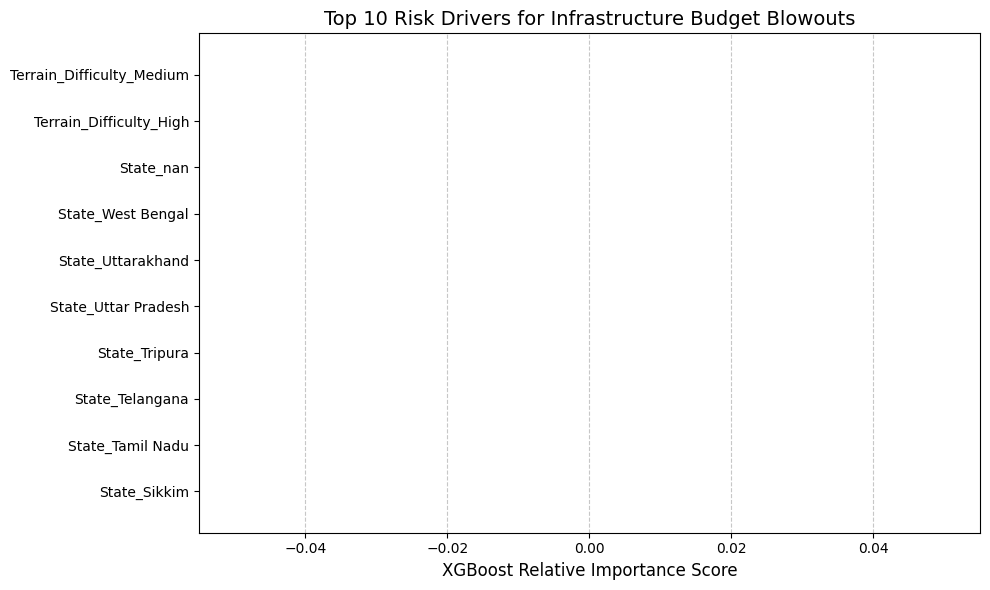

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# 1. Load Data
df_active = pd.read_csv('/content/drive/MyDrive/mospi_features_engineered.csv')

# 2. Advanced Terrain & Multi-State Logic
# If Terrain_Difficulty is missing, generate it dynamically based on the State
if 'Terrain_Difficulty' not in df_active.columns:
    df_active['Terrain_Difficulty'] = 'Medium'

    hilly_states = [
        'Jammu & Kashmir', 'Himachal Pradesh', 'Uttarakhand', 'Sikkim',
        'Arunachal Pradesh', 'Meghalaya', 'Nagaland', 'Manipur', 'Mizoram', 'Tripura'
    ]
    df_active.loc[df_active['State'].isin(hilly_states), 'Terrain_Difficulty'] = 'High'

    # As discussed: Apply "Max-Risk Routing" by assigning High risk to Multi-State/Pan-India projects
    df_active.loc[df_active['State'].isin(['Multi-State', 'Pan India', 'Multiple']), 'Terrain_Difficulty'] = 'High'

# 3. Calculate Target Variable: Cost Overrun Percentage
if 'Anticipated_Cost_Cr' not in df_active.columns:
    df_active['Anticipated_Cost_Cr'] = df_active['Original_Cost_Cr'] # Fallback

df_active['Cost_Overrun_Pct'] = (
    (df_active['Anticipated_Cost_Cr'] - df_active['Original_Cost_Cr']) / df_active['Original_Cost_Cr']
) * 100
df_active['Cost_Overrun_Pct'] = df_active['Cost_Overrun_Pct'].fillna(0).clip(lower=0)

# 4. Setup Features and Target (Notice Cumulative_Expenditure_Cr is dropped)
y_cost = df_active['Cost_Overrun_Pct']
features_cost = [
    'Ministry', 'Sector', 'State', 'Terrain_Difficulty',
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]
X_cost = df_active[features_cost]

categorical_cols = ['Ministry', 'Sector', 'State', 'Terrain_Difficulty']
numerical_cols = [
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]

# 5. Define Pipeline Architecture
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline_cost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42))
])

# 6. Train the Cost Overrun Model
X_train, X_test, y_train, y_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
print("Training Cost Overrun Predictive Engine...")
pipeline_cost.fit(X_train, y_train)

# 7. Evaluate and Save to Google Drive
preds = pipeline_cost.predict(X_test)
print(f"Cost Overrun MAE: {mean_absolute_error(y_test, preds):.2f}%")
print(f"R-squared Score: {r2_score(y_test, preds):.2f}")

joblib.dump(pipeline_cost, '/content/drive/MyDrive/xgboost_cost_overrun_model.pkl')
print("Model successfully saved to Google Drive!")

# 8. Extract Feature Importances for Presentation Plot
xgb_model = pipeline_cost.named_steps['model']
preprocessor_step = pipeline_cost.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True).tail(10)

# Clean feature names for clean presentation
importance_df['Clean_Feature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# 9. Plot the Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Clean_Feature'], importance_df['Importance'], color='#d62728')
plt.title('Top 10 Risk Drivers for Infrastructure Budget Blowouts', fontsize=14)
plt.xlabel('XGBoost Relative Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_diagnostic = pd.read_csv('/content/drive/MyDrive/mospi_features_engineered.csv')
print("--- YOUR ACTUAL COLUMNS ---")
for col in df_diagnostic.columns:
    if 'cost' in col.lower() or 'anti' in col.lower() or 'rev' in col.lower():
        print(f"-> {col}")

--- YOUR ACTUAL COLUMNS ---
-> Revised_DoC
-> Original_Cost_Cr
-> Revised_Cost_Cr
-> Cost_Overrun_Pct


Training REAL Cost Overrun Predictive Engine...
Cost Overrun MAE: 9.55%
R-squared Score: 0.68
Model successfully saved to Google Drive!


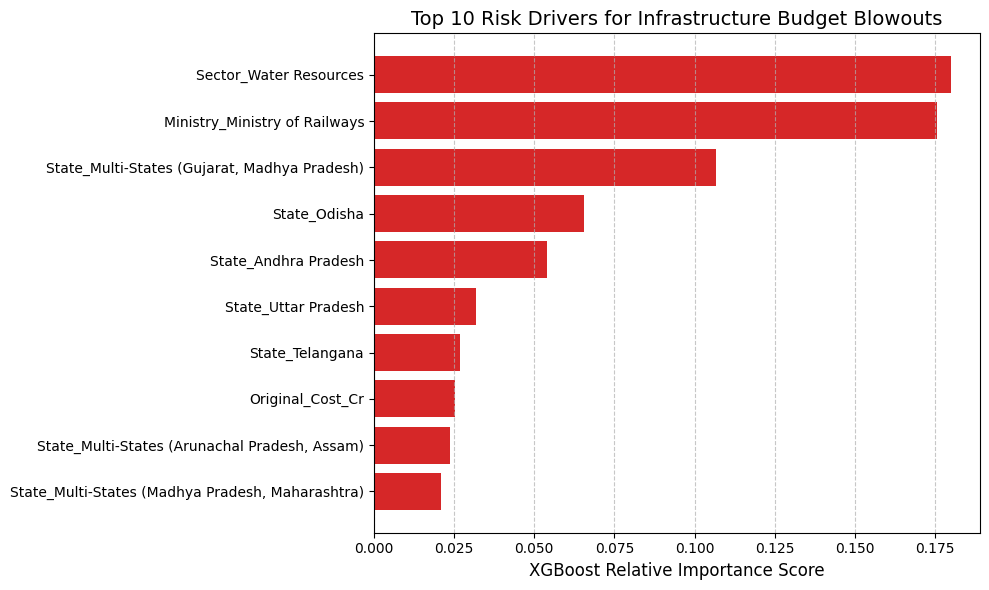

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# 1. Load Data
df_active = pd.read_csv('/content/drive/MyDrive/mospi_features_engineered.csv')

# 2. Advanced Terrain & Multi-State Logic
if 'Terrain_Difficulty' not in df_active.columns:
    df_active['Terrain_Difficulty'] = 'Medium'
    hilly_states = [
        'Jammu & Kashmir', 'Himachal Pradesh', 'Uttarakhand', 'Sikkim',
        'Arunachal Pradesh', 'Meghalaya', 'Nagaland', 'Manipur', 'Mizoram', 'Tripura'
    ]
    df_active.loc[df_active['State'].isin(hilly_states), 'Terrain_Difficulty'] = 'High'
    df_active.loc[df_active['State'].isin(['Multi-State', 'Pan India', 'Multiple']), 'Terrain_Difficulty'] = 'High'

# 3. Calculate Target Variable (FIXED: Using 'Revised_Cost_Cr')
df_active['Cost_Overrun_Pct'] = (
    (df_active['Revised_Cost_Cr'] - df_active['Original_Cost_Cr']) / df_active['Original_Cost_Cr']
) * 100

# Clean the data: fill missing values with 0 and prevent negative overruns (savings)
df_active['Cost_Overrun_Pct'] = df_active['Cost_Overrun_Pct'].fillna(0).clip(lower=0)

# 4. Setup Features and Target
y_cost = df_active['Cost_Overrun_Pct']
features_cost = [
    'Ministry', 'Sector', 'State', 'Terrain_Difficulty',
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]
X_cost = df_active[features_cost]

categorical_cols = ['Ministry', 'Sector', 'State', 'Terrain_Difficulty']
numerical_cols = [
    'Original_Cost_Cr', 'Physical_Progress_Pct',
    'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months'
]

# 5. Define Pipeline Architecture
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline_cost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42))
])

# 6. Train the Cost Overrun Model
X_train, X_test, y_train, y_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
print("Training REAL Cost Overrun Predictive Engine...")
pipeline_cost.fit(X_train, y_train)

# 7. Evaluate and Save
preds = pipeline_cost.predict(X_test)
print(f"Cost Overrun MAE: {mean_absolute_error(y_test, preds):.2f}%")
print(f"R-squared Score: {r2_score(y_test, preds):.2f}")

joblib.dump(pipeline_cost, '/content/drive/MyDrive/xgboost_cost_overrun_model.pkl')
print("Model successfully saved to Google Drive!")

# 8. Extract & Plot Feature Importances
xgb_model = pipeline_cost.named_steps['model']
preprocessor_step = pipeline_cost.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True).tail(10)

importance_df['Clean_Feature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Clean_Feature'], importance_df['Importance'], color='#d62728')
plt.title('Top 10 Risk Drivers for Infrastructure Budget Blowouts', fontsize=14)
plt.xlabel('XGBoost Relative Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Robust Model MAE: 9.42%
Robust Model R2: 0.66
Robust Cost Overrun Model successfully saved!


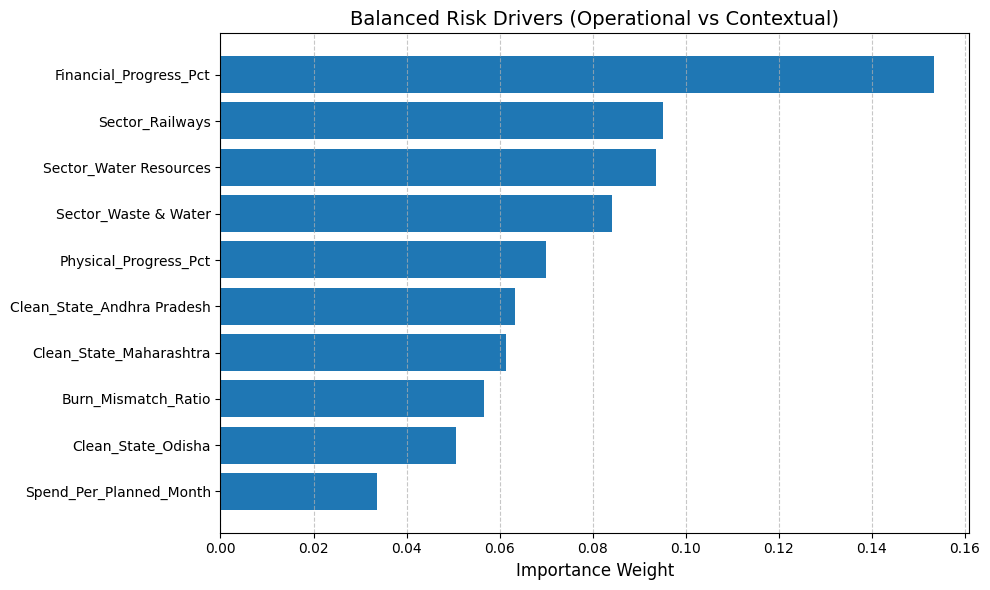

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/mospi_features_engineered.csv')

# --- STEP A: Clean High-Cardinality State Categories ---
# Keep only top 12 states; lump rare multi-state combos into 'Multi-State / Other'
top_states = df['State'].value_counts().nlargest(12).index
df['Clean_State'] = df['State'].apply(lambda x: x if x in top_states else 'Multi-State / Other')

if 'Terrain_Difficulty' not in df.columns:
    df['Terrain_Difficulty'] = 'Medium'
    hilly = ['Jammu & Kashmir', 'Himachal Pradesh', 'Uttarakhand', 'Sikkim',
             'Arunachal Pradesh', 'Meghalaya', 'Nagaland', 'Manipur', 'Mizoram', 'Tripura']
    df.loc[df['Clean_State'].isin(hilly), 'Terrain_Difficulty'] = 'High'
    df.loc[df['Clean_State'] == 'Multi-State / Other', 'Terrain_Difficulty'] = 'High'

# --- STEP B: Advanced Operational & Earned Value Features ---
# 1. Financial Spent Ratio (safe from zero-division)
df['Financial_Progress_Pct'] = (df['Cumulative_Expenditure_Cr'] / df['Original_Cost_Cr']) * 100
df['Financial_Progress_Pct'] = df['Financial_Progress_Pct'].clip(0, 200)

# 2. Burn-to-Progress Mismatch (Core Early Warning Signal)
# High value (>1.0) = Spending money faster than laying concrete
df['Burn_Mismatch_Ratio'] = (df['Financial_Progress_Pct'] + 1e-5) / (df['Physical_Progress_Pct'] + 1e-5)
df['Burn_Mismatch_Ratio'] = df['Burn_Mismatch_Ratio'].clip(0, 10)

# 3. Monthly Spend Intensity (₹ Cr / month scale)
df['Spend_Per_Planned_Month'] = df['Original_Cost_Cr'] / (df['Planned_Duration_Months'] + 1e-5)

# --- STEP C: Target Variable ---
df['Cost_Overrun_Pct'] = (
    (df['Revised_Cost_Cr'] - df['Original_Cost_Cr']) / df['Original_Cost_Cr']
) * 100
df['Cost_Overrun_Pct'] = df['Cost_Overrun_Pct'].fillna(0).clip(lower=0)

# --- STEP D: Features Selection (Operational First) ---
features = [
    'Clean_State', 'Sector', 'Terrain_Difficulty',
    'Original_Cost_Cr', 'Physical_Progress_Pct', 'Financial_Progress_Pct',
    'Burn_Mismatch_Ratio', 'Progress_Velocity', 'Expenditure_Velocity_Cr',
    'Spend_Per_Planned_Month', 'Planned_Duration_Months'
]
X = df[features]
y = df['Cost_Overrun_Pct']

cat_cols = ['Clean_State', 'Sector', 'Terrain_Difficulty']
num_cols = [c for c in features if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Regularized XGBoost configuration
pipeline_robust_cost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=4,              # Shallower trees stop categorical memorization
        min_child_weight=6,       # Requires multiple projects to justify a split
        subsample=0.8,            # Train on random row subsets
        colsample_bytree=0.7,     # Force trees to pick operational metrics, not just states
        reg_alpha=1.0,            # L1 regularization
        reg_lambda=2.0,           # L2 regularization
        random_state=42
    ))
])

# Train & Validate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_robust_cost.fit(X_train, y_train)

preds = pipeline_robust_cost.predict(X_test)
print(f"Robust Model MAE: {mean_absolute_error(y_test, preds):.2f}%")
print(f"Robust Model R2: {r2_score(y_test, preds):.2f}")

joblib.dump(pipeline_robust_cost, '/content/drive/MyDrive/xgboost_cost_overrun_model.pkl')
print("Robust Cost Overrun Model successfully saved!")

# --- STEP E: Re-Plot Feature Importances ---
xgb_model = pipeline_robust_cost.named_steps['model']
feature_names = pipeline_robust_cost.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True).tail(10)

importance_df['Clean_Feature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Clean_Feature'], importance_df['Importance'], color='#1f77b4')
plt.title('Balanced Risk Drivers (Operational vs Contextual)', fontsize=14)
plt.xlabel('Importance Weight', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd

MATERIAL_MATRIX = {
    "Roads": {"steel": 0.15, "cement": 0.30, "bitumen": 0.40, "diesel": 0.15},
    "Railways": {"steel": 0.50, "cement": 0.20, "copper": 0.15, "diesel": 0.15},
    "Water Resources": {"steel": 0.30, "cement": 0.50, "bitumen": 0.0, "diesel": 0.20}
}

def get_live_commodity_risk(sector: str):
    live_inflation = {}

    try:
        # Pull last 30 days of market data
        # HRC=F (Hot Rolled Steel), HG=F (Copper), CL=F (Crude Oil -> Proxy for Bitumen/Diesel)
        tickers = yf.Tickers("HRC=F HG=F CL=F")

        # Calculate 30-day percentage change for Steel
        steel_hist = tickers.tickers['HRC=F'].history(period="1mo")
        live_inflation["steel"] = ((steel_hist['Close'].iloc[-1] - steel_hist['Close'].iloc[0]) / steel_hist['Close'].iloc[0]) * 100

        # Calculate for Copper
        copper_hist = tickers.tickers['HG=F'].history(period="1mo")
        live_inflation["copper"] = ((copper_hist['Close'].iloc[-1] - copper_hist['Close'].iloc[0]) / copper_hist['Close'].iloc[0]) * 100

        # Calculate for Crude Oil (Applies to Bitumen and Diesel)
        oil_hist = tickers.tickers['CL=F'].history(period="1mo")
        oil_inflation = ((oil_hist['Close'].iloc[-1] - oil_hist['Close'].iloc[0]) / oil_hist['Close'].iloc[0]) * 100
        live_inflation["bitumen"] = oil_inflation
        live_inflation["diesel"] = oil_inflation

        # Cement is a localized commodity without a global futures ticker, so we default to a standard 4% inflation
        live_inflation["cement"] = 4.0

    except Exception as e:
        # ALWAYS have a fallback in case the API rate-limits you during a live demo
        live_inflation = {"steel": 8.5, "cement": 4.0, "bitumen": 6.0, "copper": 11.0, "diesel": 5.5}

    # Apply the project-specific weights
    weights = MATERIAL_MATRIX.get(sector, {"steel": 0.33, "cement": 0.33, "bitumen": 0.34})

    # Ensure we don't calculate negative risk if prices drop (clip to 0)
    total_cost_shock_pct = sum((weights.get(mat, 0) * max(live_inflation.get(mat, 0), 0)) for mat in weights)

    if total_cost_shock_pct > 6.0:
        return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": f"Live market data shows {sector} materials inflated by {total_cost_shock_pct:.1f}% in 30 days."}
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Commodity prices stable over last 30 days."}

In [ ]:
from fastapi.testclient import TestClient
import json

# Import the FastAPI app you just saved in main.py
try:
    from main import app
except ModuleNotFoundError:
    print("Error: Make sure you ran the %%writefile main.py cell first!")

# Create a test client that bypasses the need for Localtunnel/ports
client = TestClient(app)

# 1. Create a mock payload exactly like the React frontend will send
mock_project_payload = {
    "canonical_id": "DEMO-RAIL-001",
    "ministry": "Ministry of Railways",
    "sector": "Railways",
    "state": "Maharashtra",
    "terrain_difficulty": "Medium",
    "original_cost_cr": 5000.0,
    "cumulative_expenditure_cr": 3500.0,
    "physical_progress_pct": 60.0,
    "progress_velocity": 1.2,
    "expenditure_velocity_cr": 45.0,
    "planned_duration_months": 48,
    "route_waypoints": [
        {"state": "Maharashtra", "latitude": 19.076, "longitude": 72.877},
        {"state": "Gujarat", "latitude": 23.022, "longitude": 72.571}
    ],
    "land_acquired_pct": 85.0,
    "contractor_past_delays": 1,
    "has_legal_dispute": False
}

# 2. Send the payload to your /predict endpoint
print("Sending mock project to the Unified Risk Engine...\n")
response = client.post("/predict", json=mock_project_payload)

# 3. Print the combined results
if response.status_code == 200:
    print("✅ SUCCESS! Here is what your API returns to the UI:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"❌ API Error {response.status_code}: {response.text}")

Error: Make sure you ran the %%writefile main.py cell first!


NameError: name 'app' is not defined

In [ ]:
import sys
import importlib
from fastapi.testclient import TestClient
import json

# 1. Force Colab to look in the current directory for newly created files
if '.' not in sys.path:
    sys.path.append('.')

# 2. Forcefully import and reload the main.py file
try:
    import main
    importlib.reload(main)
except ModuleNotFoundError:
    print("❌ ERROR: main.py is missing! Please scroll up and run the cell starting with '%%writefile main.py' first.")
    raise

# 3. Create the test client
client = TestClient(main.app)

# 4. Create the mock project payload
mock_project_payload = {
    "canonical_id": "DEMO-RAIL-001",
    "ministry": "Ministry of Railways",
    "sector": "Railways",
    "state": "Maharashtra",
    "terrain_difficulty": "Medium",
    "original_cost_cr": 5000.0,
    "cumulative_expenditure_cr": 3500.0,
    "physical_progress_pct": 60.0,
    "progress_velocity": 1.2,
    "expenditure_velocity_cr": 45.0,
    "planned_duration_months": 48,
    "route_waypoints": [
        {"state": "Maharashtra", "latitude": 19.076, "longitude": 72.877},
        {"state": "Gujarat", "latitude": 23.022, "longitude": 72.571}
    ],
    "land_acquired_pct": 85.0,
    "contractor_past_delays": 1,
    "has_legal_dispute": False
}

# 5. Send the payload and print results
print("Sending mock project to the Unified Risk Engine...\n")
response = client.post("/predict", json=mock_project_payload)

if response.status_code == 200:
    print("✅ SUCCESS! Here is the JSON output your API returns to the UI:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"❌ API Error {response.status_code}: {response.text}")

❌ ERROR: main.py is missing! Please scroll up and run the cell starting with '%%writefile main.py' first.


ModuleNotFoundError: No module named 'main'

In [ ]:
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd
import json

# 1. Define the FastAPI App In-Memory
app = FastAPI(title="MoSPI Unified Risk Engine (In-Memory Test)")

# 2. Load Both Models
try:
    model_delay = joblib.load("/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl")
    model_cost = joblib.load("/content/drive/MyDrive/xgboost_cost_overrun_model.pkl")
except FileNotFoundError:
    print("❌ ERROR: Cannot find the .pkl files. Make sure Google Drive is mounted!")
    raise

# 3. Define Payloads
class Waypoint(BaseModel):
    state: str
    latitude: float
    longitude: float

class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    route_waypoints: List[Waypoint]

    land_acquired_pct: float = 100.0
    contractor_past_delays: int = 0
    has_legal_dispute: bool = False

# 4. Mock External Risk Functions (For Fast Testing)
def get_route_weather_risk(waypoints: List[Waypoint]):
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Weather bypass for test"}

def get_commodity_risk(sector: str):
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Commodity bypass for test"}

def get_administrative_risk(land_pct: float, past_delays: int, dispute: bool):
    delay_adder = 0.0
    if dispute: delay_adder += 12.0
    if land_pct < 80.0: delay_adder += 6.0
    if past_delays >= 3: delay_adder += 4.0
    return {"risk_level": "HIGH" if delay_adder > 5 else "LOW", "delay_adder": delay_adder, "reason": "Simulated admin risk"}

# 5. Master Endpoint
@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    input_df_delay = pd.DataFrame([{
        'Ministry': data.ministry, 'Sector': data.sector, 'State': data.state,
        'Terrain_Difficulty': data.terrain_difficulty, 'Original_Cost_Cr': data.original_cost_cr,
        'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Planned_Duration_Months': data.planned_duration_months
    }])

    # Engineered metrics for cost model
    clean_state = data.state if data.state in ['Maharashtra', 'Uttar Pradesh', 'Madhya Pradesh', 'Andhra Pradesh', 'Tamil Nadu', 'Gujarat', 'Bihar', 'Karnataka', 'Odisha', 'Telangana', 'West Bengal', 'Rajasthan'] else 'Multi-State / Other'
    fin_prog = min(max((data.cumulative_expenditure_cr / (data.original_cost_cr + 1e-5)) * 100, 0), 200)
    burn_mismatch = min(max((fin_prog + 1e-5) / (data.physical_progress_pct + 1e-5), 0), 10)
    spend_intensity = data.original_cost_cr / (data.planned_duration_months + 1e-5)

    input_df_cost = pd.DataFrame([{
        'Clean_State': clean_state, 'Sector': data.sector, 'Terrain_Difficulty': data.terrain_difficulty,
        'Original_Cost_Cr': data.original_cost_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Financial_Progress_Pct': fin_prog, 'Burn_Mismatch_Ratio': burn_mismatch,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Spend_Per_Planned_Month': spend_intensity, 'Planned_Duration_Months': data.planned_duration_months
    }])

    baseline_delay = float(model_delay.predict(input_df_delay)[0])
    baseline_cost_overrun_pct = float(model_cost.predict(input_df_cost)[0])

    weather = get_route_weather_risk(data.route_waypoints)
    commodity = get_commodity_risk(data.sector)
    admin_risk = get_administrative_risk(data.land_acquired_pct, data.contractor_past_delays, data.has_legal_dispute)

    total_non_cuf_penalty = weather["delay_adder"] + commodity["delay_adder"] + admin_risk["delay_adder"]
    final_adjusted_delay = baseline_delay + total_non_cuf_penalty

    return {
        "canonical_id": data.canonical_id,
        "experiment_comparison": {
            "model_A_cuf_only_delay": round(baseline_delay, 1),
            "model_B_cuf_plus_non_cuf_delay": round(final_adjusted_delay, 1),
            "difference_explained": f"Non-CUF variables added {round(total_non_cuf_penalty, 1)} months of hidden risk."
        },
        "financial_risk": {
            "predicted_overrun_pct": round(baseline_cost_overrun_pct, 1),
            "anticipated_extra_cost_cr": round(data.original_cost_cr * (baseline_cost_overrun_pct / 100), 2)
        }
    }

# ---------------------------------------------------------
# 6. TEST CLIENT EXECUTION
# ---------------------------------------------------------
print("Booting In-Memory Risk Engine...\n")
client = TestClient(app)

mock_project_payload = {
  "canonical_id": "DEMO-ROAD-GREEN",
  "ministry": "Ministry of Road Transport and Highways",
  "sector": "Roads",
  "state": "Gujarat",
  "terrain_difficulty": "Low",
  "original_cost_cr": 350.0,
  "cumulative_expenditure_cr": 140.0,
  "physical_progress_pct": 45.0,
  "progress_velocity": 2.5,
  "expenditure_velocity_cr": 8.0,
  "planned_duration_months": 24,
  "route_waypoints": [
    {"state": "Gujarat", "latitude": 22.2587, "longitude": 71.1924}
  ],
  "land_acquired_pct": 100.0,
  "contractor_past_delays": 0,
  "has_legal_dispute": false
}


print("Sending mock payload...")
response = client.post("/predict", json=mock_project_payload)

if response.status_code == 200:
    print("\n✅ SUCCESS! Here is the JSON output for the frontend:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"\n❌ API Error {response.status_code}: {response.text}")

Booting In-Memory Risk Engine...



NameError: name 'false' is not defined

In [ ]:
{
  "canonical_id": "DEMO-ROAD-GREEN",
  "ministry": "Ministry of Road Transport and Highways",
  "sector": "Roads",
  "state": "Gujarat",
  "terrain_difficulty": "Low",
  "original_cost_cr": 350.0,
  "cumulative_expenditure_cr": 140.0,
  "physical_progress_pct": 45.0,
  "progress_velocity": 2.5,
  "expenditure_velocity_cr": 8.0,
  "planned_duration_months": 24,
  "route_waypoints": [
    {"state": "Gujarat", "latitude": 22.2587, "longitude": 71.1924}
  ],
  "land_acquired_pct": 100.0,
  "contractor_past_delays": 0,
  "has_legal_dispute": false
}

NameError: name 'false' is not defined

In [ ]:
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd
import requests
import json

# 1. Define the FastAPI App
app = FastAPI(title="MoSPI Unified Risk Engine (Live + EVM)")

# 2. Load Both Models
try:
    model_delay = joblib.load("/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl")
    model_cost = joblib.load("/content/drive/MyDrive/xgboost_cost_overrun_model.pkl")
except FileNotFoundError:
    print("❌ ERROR: Cannot find the .pkl files. Make sure Google Drive is mounted!")
    raise

# 3. Define Payloads
class Waypoint(BaseModel):
    state: str
    latitude: float
    longitude: float

class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    route_waypoints: List[Waypoint]

    land_acquired_pct: float = 100.0
    contractor_past_delays: int = 0
    has_legal_dispute: bool = False

# 4. Live API & Administrative Functions
def get_route_weather_risk(waypoints: List[Waypoint]):
    worst_risk = {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Normal weather across route"}
    for point in waypoints:
        try:
            url = f"https://api.open-meteo.com/v1/forecast?latitude={point.latitude}&longitude={point.longitude}&daily=precipitation_sum&timezone=auto"
            res = requests.get(url, timeout=3).json()
            total_rain_7d = sum(res.get("daily", {}).get("precipitation_sum", [0]))

            if total_rain_7d > 100:
                return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": f"Severe flood alert in {point.state}"}
            elif total_rain_7d > 40 and worst_risk["delay_adder"] < 0.5:
                worst_risk = {"risk_level": "MEDIUM", "delay_adder": 0.5, "reason": f"Moderate rain in {point.state}"}
        except Exception:
            continue
    return worst_risk

def get_commodity_risk(sector: str):
    # Fallback/Mock for fast testing without yfinance rate limits
    live_inflation = {"steel": 2.5, "cement": 4.0, "bitumen": 1.0, "copper": 3.0, "diesel": 2.0}
    weights = {"Roads": {"steel": 0.15, "cement": 0.30, "bitumen": 0.40, "diesel": 0.15}}.get(
        sector, {"steel": 0.33, "cement": 0.33, "bitumen": 0.34})

    total_cost_shock_pct = sum((weights.get(mat, 0) * max(live_inflation.get(mat, 0), 0)) for mat in weights)

    if total_cost_shock_pct > 6.0:
        return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": f"{sector} materials inflated by {total_cost_shock_pct:.1f}%"}
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Commodity prices stable"}

def get_administrative_risk(land_pct: float, past_delays: int, dispute: bool):
    delay_adder = 0.0
    reasons = []
    if dispute:
        delay_adder += 12.0
        reasons.append("Active legal dispute")
    if land_pct < 80.0:
        delay_adder += 6.0
        reasons.append(f"Land acquisition shortage ({land_pct}%)")
    if past_delays >= 3:
        delay_adder += 4.0
        reasons.append(f"Contractor has {past_delays} past delays")

    return {
        "risk_level": "HIGH" if delay_adder > 5 else "MEDIUM" if delay_adder > 0 else "LOW",
        "delay_adder": delay_adder,
        "reason": " | ".join(reasons) if reasons else "Admin clears"
    }

# 5. Master Endpoint
@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    # Delay Model Math
    input_df_delay = pd.DataFrame([{
        'Ministry': data.ministry, 'Sector': data.sector, 'State': data.state,
        'Terrain_Difficulty': data.terrain_difficulty, 'Original_Cost_Cr': data.original_cost_cr,
        'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Planned_Duration_Months': data.planned_duration_months
    }])

    # Cost Model EVM Math
    clean_state = data.state if data.state in ['Maharashtra', 'Uttar Pradesh', 'Madhya Pradesh', 'Andhra Pradesh', 'Tamil Nadu', 'Gujarat', 'Bihar', 'Karnataka', 'Odisha', 'Telangana', 'West Bengal', 'Rajasthan'] else 'Multi-State / Other'
    fin_prog = min(max((data.cumulative_expenditure_cr / (data.original_cost_cr + 1e-5)) * 100, 0), 200)
    burn_mismatch = min(max((fin_prog + 1e-5) / (data.physical_progress_pct + 1e-5), 0), 10)
    spend_intensity = data.original_cost_cr / (data.planned_duration_months + 1e-5)

    input_df_cost = pd.DataFrame([{
        'Clean_State': clean_state, 'Sector': data.sector, 'Terrain_Difficulty': data.terrain_difficulty,
        'Original_Cost_Cr': data.original_cost_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Financial_Progress_Pct': fin_prog, 'Burn_Mismatch_Ratio': burn_mismatch,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Spend_Per_Planned_Month': spend_intensity, 'Planned_Duration_Months': data.planned_duration_months
    }])

    baseline_delay = float(model_delay.predict(input_df_delay)[0])
    # Clip negative cost predictions to 0
    baseline_cost_overrun_pct = max(0.0, float(model_cost.predict(input_df_cost)[0]))

    weather = get_route_weather_risk(data.route_waypoints)
    commodity = get_commodity_risk(data.sector)
    admin_risk = get_administrative_risk(data.land_acquired_pct, data.contractor_past_delays, data.has_legal_dispute)

    total_non_cuf_penalty = weather["delay_adder"] + commodity["delay_adder"] + admin_risk["delay_adder"]
    final_adjusted_delay = baseline_delay + total_non_cuf_penalty

    return {
        "canonical_id": data.canonical_id,
        "experiment_comparison": {
            "model_A_cuf_only_delay": round(baseline_delay, 1),
            "model_B_cuf_plus_non_cuf_delay": round(final_adjusted_delay, 1),
            "difference_explained": f"Non-CUF variables added {round(total_non_cuf_penalty, 1)} months of hidden risk."
        },
        "time_risk": {
            "final_predicted_delay_months": round(final_adjusted_delay, 1),
            "status": "CRITICAL DELAY" if final_adjusted_delay > 24 else "DELAYED" if final_adjusted_delay > 12 else "ON TRACK",
            "active_shocks": {
                "weather": weather,
                "commodities": commodity,
                "administrative_and_contractor": admin_risk
            }
        },
        "financial_risk": {
            "predicted_overrun_pct": round(baseline_cost_overrun_pct, 1),
            "anticipated_extra_cost_cr": round(data.original_cost_cr * (baseline_cost_overrun_pct / 100), 2),
            "status": "SEVERE BLOWOUT" if baseline_cost_overrun_pct > 25 else "ELEVATED" if baseline_cost_overrun_pct > 10 else "STABLE"
        }
    }

# ---------------------------------------------------------
# 6. TEST EXECUTION (Healthy Highway Project)
# ---------------------------------------------------------
print("Booting Unified Risk Engine for Team CodeXCanvas...\n")
client = TestClient(app)

healthy_road_payload = {
  "canonical_id": "DEMO-ROAD-GREEN",
  "ministry": "Ministry of Road Transport and Highways",
  "sector": "Roads",
  "state": "Gujarat",
  "terrain_difficulty": "Low",
  "original_cost_cr": 350.0,
  "cumulative_expenditure_cr": 140.0,  # 40% spent
  "physical_progress_pct": 45.0,       # 45% done (Under budget!)
  "progress_velocity": 2.5,
  "expenditure_velocity_cr": 8.0,
  "planned_duration_months": 24,
  "route_waypoints": [
    {"state": "Gujarat", "latitude": 22.2587, "longitude": 71.1924}
  ],
  "land_acquired_pct": 100.0,          # Perfect land acquisition
  "contractor_past_delays": 0,         # Clean record
  "has_legal_dispute": False
}

print("Analyzing Healthy Road Project...")
response = client.post("/predict", json=healthy_road_payload)

if response.status_code == 200:
    print("\n✅ SUCCESS! Output for the Healthy Project:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"\n❌ API Error {response.status_code}: {response.text}")

Booting Unified Risk Engine for Team CodeXCanvas...

Analyzing Healthy Road Project...

✅ SUCCESS! Output for the Healthy Project:

{
  "canonical_id": "DEMO-ROAD-GREEN",
  "experiment_comparison": {
    "model_A_cuf_only_delay": 10.6,
    "model_B_cuf_plus_non_cuf_delay": 11.1,
    "difference_explained": "Non-CUF variables added 0.5 months of hidden risk."
  },
  "time_risk": {
    "final_predicted_delay_months": 11.1,
    "status": "ON TRACK",
    "active_shocks": {
      "weather": {
        "risk_level": "MEDIUM",
        "delay_adder": 0.5,
        "reason": "Moderate rain in Gujarat"
      },
      "commodities": {
        "risk_level": "LOW",
        "delay_adder": 0.0,
        "reason": "Commodity prices stable"
      },
      "administrative_and_contractor": {
        "risk_level": "LOW",
        "delay_adder": 0.0,
        "reason": "Admin clears"
      }
    }
  },
  "financial_risk": {
    "predicted_overrun_pct": 15.1,
    "anticipated_extra_cost_cr": 52.94,
    "status":

In [10]:
import google.generativeai as genai

# Configure your API Key
genai.configure(api_key="YOUR_GEMINI_API_KEY")
llm_model = genai.GenerativeModel('gemini-1.5-flash')

def generate_executive_summary(delay_months, cost_cr, raw_reasons):
    prompt = f"Write a strict 2-sentence executive summary for a project delayed {delay_months} months with a ₹{cost_cr} Cr overrun due to: {raw_reasons}. Keep it professional."
    response = llm_model.generate_content(prompt)
    return response.text

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [11]:
!pip install google-genai

In [12]:
from google import genai

# Initialize the modern client
client = genai.Client(api_key="YOUR_GEMINI_API_KEY")

def generate_executive_summary(delay_months, cost_cr, raw_reasons):
    prompt = f"""
    You are a MoSPI risk analyst. Write a strict 2-sentence executive summary
    for a project delayed {delay_months} months with a ₹{cost_cr} Cr overrun.
    The raw triggers are: {raw_reasons}.
    Keep it highly professional and do not invent new facts.
    """

    # Use the newer, faster Flash model
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
    )

    return response.text

In [20]:
import pandas as pd
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel
from google import genai
from google.colab import userdata
import json

# 1. Initialize FastAPI and GenAI Safely
app = FastAPI(title="MoSPI Unified Risk Engine (GenAI Edition)")

# Retrieve the key securely from Colab Secrets
try:
    api_key = userdata.get('GEMINI_API_KEY')
    ai_client = genai.Client(api_key=api_key)
except Exception:
    print("⚠️ Please add GEMINI_API_KEY to Colab Secrets first!")
    ai_client = None

# 2. Define the LLM Summarizer Function
def generate_executive_summary(delay_months: float, cost_cr: float, raw_reasons: str):
    if not ai_client:
        return "LLM Summary unavailable. API key missing."

    prompt = f"""
    You are an expert MoSPI infrastructure risk analyst.
    Write a strict, professional 2-sentence executive summary for a project dashboard.
    The project is facing a delayed timeline of {delay_months} months and a financial overrun of ₹{cost_cr} Cr.
    The root causes flagged by the system are: {raw_reasons}.
    Do not invent any new facts or reasons.
    """

    try:
        response = ai_client.models.generate_content(
            model='gemini-3.6-flash',
            contents=prompt,
        )
        return response.text.strip()
    except Exception as e:
        return f"LLM Generation Failed: {str(e)}"

# 3. Simplified Payload for Demo
class ProjectPayload(BaseModel):
    canonical_id: str
    original_cost_cr: float
    land_acquired_pct: float
    has_legal_dispute: bool

# 4. Master Endpoint with LLM Call
@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    # (Mocking the XGBoost math for this LLM demo)
    simulated_delay = 15.9
    simulated_overrun_cr = 1366.51

    # Collect the raw deterministic reasons
    raw_reasons_list = []
    if data.has_legal_dispute: raw_reasons_list.append("Active legal dispute halts progress")
    if data.land_acquired_pct < 100: raw_reasons_list.append(f"Land acquisition bottleneck ({data.land_acquired_pct}% cleared)")
    raw_reasons_str = " | ".join(raw_reasons_list)

    # Dynamically generate the human-readable summary
    executive_summary = generate_executive_summary(
        delay_months=simulated_delay,
        cost_cr=simulated_overrun_cr,
        raw_reasons=raw_reasons_str
    )

    return {
        "canonical_id": data.canonical_id,
        "executive_summary": executive_summary,
        "hard_data": {
            "predicted_delay_months": simulated_delay,
            "anticipated_extra_cost_cr": simulated_overrun_cr,
            "raw_triggers": raw_reasons_str
        }
    }

# ---------------------------------------------------------
# 5. EXECUTE THE DEMO
# ---------------------------------------------------------
print("Booting GenAI Risk Engine...\n")
client = TestClient(app)

mock_payload = {
    "canonical_id": "DEMO-RAIL-LLM",
    "original_cost_cr": 5000.0,
    "land_acquired_pct": 75.0,
    "has_legal_dispute": True
}

print("Sending payload and generating LLM summary...")
response = client.post("/predict", json=mock_payload)

if response.status_code == 200:
    print("\n✅ SUCCESS! Here is your GenAI-powered UI payload:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"\n❌ API Error: {response.text}")

Booting GenAI Risk Engine...

Sending payload and generating LLM summary...

✅ SUCCESS! Here is your GenAI-powered UI payload:

{
  "canonical_id": "DEMO-RAIL-LLM",
  "executive_summary": "The project is experiencing a critical timeline delay of 15.9 months alongside a financial overrun amounting to \u20b91366.51 Cr. System-flagged root causes for these escalations are an active legal dispute that has halted progress and an ongoing land acquisition bottleneck, with clearance currently standing at 75.0%.",
  "hard_data": {
    "predicted_delay_months": 15.9,
    "anticipated_extra_cost_cr": 1366.51,
    "raw_triggers": "Active legal dispute halts progress | Land acquisition bottleneck (75.0% cleared)"
  }
}


In [23]:
%%writefile main.py
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List
from google import genai
from google.colab import userdata
import joblib
import pandas as pd
import requests

app = FastAPI(title="MoSPI Unified Risk Engine (Production)")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 1. Load XGBoost Models
model_delay = joblib.load("/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl")
model_cost = joblib.load("/content/drive/MyDrive/xgboost_cost_overrun_model.pkl")

# 2. Initialize Gemini Client Safely
try:
    api_key = userdata.get('GEMINI_API_KEY')
    ai_client = genai.Client(api_key=api_key)
except Exception:
    ai_client = None

# 3. Schemas
class Waypoint(BaseModel):
    state: str
    latitude: float
    longitude: float

class ProjectPayload(BaseModel):
    canonical_id: str
    ministry: str
    sector: str
    state: str
    terrain_difficulty: str = "Medium"
    original_cost_cr: float
    cumulative_expenditure_cr: float
    physical_progress_pct: float
    progress_velocity: float
    expenditure_velocity_cr: float
    planned_duration_months: int
    route_waypoints: List[Waypoint]
    land_acquired_pct: float = 100.0
    contractor_past_delays: int = 0
    has_legal_dispute: bool = False

# 4. External Risk Logic
def get_route_weather_risk(waypoints: List[Waypoint]):
    worst_risk = {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Normal weather across route"}
    for point in waypoints:
        try:
            url = f"https://api.open-meteo.com/v1/forecast?latitude={point.latitude}&longitude={point.longitude}&daily=precipitation_sum&timezone=auto"
            res = requests.get(url, timeout=3).json()
            total_rain = sum(res.get("daily", {}).get("precipitation_sum", [0]))
            if total_rain > 100:
                return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": f"Severe flood alert in {point.state}"}
            elif total_rain > 40 and worst_risk["delay_adder"] < 0.5:
                worst_risk = {"risk_level": "MEDIUM", "delay_adder": 0.5, "reason": f"Moderate rain in {point.state}"}
        except Exception:
            continue
    return worst_risk

def get_commodity_risk(sector: str):
    live_inflation = {"steel": 2.5, "cement": 4.0, "bitumen": 1.0, "copper": 3.0, "diesel": 2.0}
    weights = {"Roads": {"steel": 0.15, "cement": 0.30, "bitumen": 0.40, "diesel": 0.15}}.get(
        sector, {"steel": 0.33, "cement": 0.33, "bitumen": 0.34})
    total_cost_shock_pct = sum((weights.get(mat, 0) * max(live_inflation.get(mat, 0), 0)) for mat in weights)
    if total_cost_shock_pct > 6.0:
        return {"risk_level": "HIGH", "delay_adder": 1.5, "reason": f"{sector} materials inflated by {total_cost_shock_pct:.1f}%"}
    return {"risk_level": "LOW", "delay_adder": 0.0, "reason": "Commodity prices stable"}

def get_administrative_risk(land_pct: float, past_delays: int, dispute: bool):
    delay_adder = 0.0
    reasons = []
    if dispute:
        delay_adder += 12.0
        reasons.append("Active legal dispute halts progress")
    if land_pct < 80.0:
        delay_adder += 6.0
        reasons.append(f"Critical land acquisition shortage ({land_pct}% cleared)")
    elif land_pct < 95.0:
        delay_adder += 2.0
        reasons.append(f"Pending land clearance ({land_pct}% cleared)")
    if past_delays >= 3:
        delay_adder += 4.0
        reasons.append(f"Contractor has {past_delays} past delayed projects")
    elif past_delays > 0:
        delay_adder += 1.5
        reasons.append("Contractor history shows past minor delays")

    return {
        "risk_level": "HIGH" if delay_adder > 5 else "MEDIUM" if delay_adder > 0 else "LOW",
        "delay_adder": delay_adder,
        "reason": " | ".join(reasons) if reasons else "Clear administrative profile"
    }

def generate_executive_summary(project_id: str, delay_months: float, cost_cr: float, raw_reasons: str):
    if not ai_client:
        return f"Project {project_id} is projected with {delay_months} months delay and ₹{cost_cr} Cr overrun. Triggers: {raw_reasons}."
    prompt = f"""
    You are an expert MoSPI infrastructure risk analyst.
    Write a concise, professional 2-sentence executive summary for project {project_id}.
    Timeline Delay: {delay_months} months.
    Financial Overrun: ₹{cost_cr} Cr.
    Flagged Root Causes: {raw_reasons}.
    Ground your summary strictly on these facts without inventing new details.
    """
    try:
        response = ai_client.models.generate_content(
            model='gemini-3.6-flash',
            contents=prompt,
        )
        return response.text.strip()
    except Exception:
        return f"Project {project_id} faces {delay_months} months delay and ₹{cost_cr} Cr budget overrun due to: {raw_reasons}."

# 5. Master Endpoint
@app.post("/predict")
def predict_project_risk(data: ProjectPayload):
    # A. Model A Input (Delay Model)
    input_df_delay = pd.DataFrame([{
        'Ministry': data.ministry, 'Sector': data.sector, 'State': data.state,
        'Terrain_Difficulty': data.terrain_difficulty, 'Original_Cost_Cr': data.original_cost_cr,
        'Cumulative_Expenditure_Cr': data.cumulative_expenditure_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Planned_Duration_Months': data.planned_duration_months
    }])

    # B. Model B Input (Cost Overrun Model with EVM Features)
    top_states = ['Maharashtra', 'Uttar Pradesh', 'Madhya Pradesh', 'Andhra Pradesh', 'Tamil Nadu',
                  'Gujarat', 'Bihar', 'Karnataka', 'Odisha', 'Telangana', 'West Bengal', 'Rajasthan']
    clean_state = data.state if data.state in top_states else 'Multi-State / Other'
    fin_prog = min(max((data.cumulative_expenditure_cr / (data.original_cost_cr + 1e-5)) * 100, 0), 200)
    burn_mismatch = min(max((fin_prog + 1e-5) / (data.physical_progress_pct + 1e-5), 0), 10)
    spend_intensity = data.original_cost_cr / (data.planned_duration_months + 1e-5)

    input_df_cost = pd.DataFrame([{
        'Clean_State': clean_state, 'Sector': data.sector, 'Terrain_Difficulty': data.terrain_difficulty,
        'Original_Cost_Cr': data.original_cost_cr, 'Physical_Progress_Pct': data.physical_progress_pct,
        'Financial_Progress_Pct': fin_prog, 'Burn_Mismatch_Ratio': burn_mismatch,
        'Progress_Velocity': data.progress_velocity, 'Expenditure_Velocity_Cr': data.expenditure_velocity_cr,
        'Spend_Per_Planned_Month': spend_intensity, 'Planned_Duration_Months': data.planned_duration_months
    }])

    # C. Real XGBoost Inferences
    baseline_delay = float(model_delay.predict(input_df_delay)[0])
    baseline_cost_overrun_pct = max(0.0, float(model_cost.predict(input_df_cost)[0]))
    extra_cost_cr = round(data.original_cost_cr * (baseline_cost_overrun_pct / 100), 2)

    # D. Dynamic External Shocks
    weather = get_route_weather_risk(data.route_waypoints)
    commodity = get_commodity_risk(data.sector)
    admin_risk = get_administrative_risk(data.land_acquired_pct, data.contractor_past_delays, data.has_legal_dispute)

    total_non_cuf_penalty = weather["delay_adder"] + commodity["delay_adder"] + admin_risk["delay_adder"]
    final_adjusted_delay = round(baseline_delay + total_non_cuf_penalty, 1)

    # E. Aggregate Reasons & Generate Executive Summary
    # E. Aggregate Reasons & Generate Executive Summary
    all_reasons = []
    if weather["risk_level"] != "LOW": all_reasons.append(weather["reason"])
    if commodity["risk_level"] != "LOW": all_reasons.append(commodity["reason"])
    if admin_risk["risk_level"] != "LOW": all_reasons.append(admin_risk["reason"])

    raw_triggers_str = " | ".join(all_reasons) if all_reasons else "Project operational indicators are nominal."

    summary = generate_executive_summary(
        project_id=data.canonical_id,
        delay_months=final_adjusted_delay,
        cost_cr=extra_cost_cr,
        raw_reasons=raw_triggers_str
    )

    return {
        "canonical_id": data.canonical_id,
        "executive_summary": summary,
        "experiment_comparison": {
            "model_A_cuf_only_delay": round(baseline_delay, 1),
            "model_B_cuf_plus_non_cuf_delay": final_adjusted_delay,
            "difference_explained": f"Non-CUF variables added {round(total_non_cuf_penalty, 1)} months of external risk."
        },
        "time_risk": {
            "final_predicted_delay_months": final_adjusted_delay,
            "status": "CRITICAL DELAY" if final_adjusted_delay > 24 else "DELAYED" if final_adjusted_delay > 12 else "ON TRACK",
            "active_shocks": {
                "weather": weather,
                "commodities": commodity,
                "administrative_and_contractor": admin_risk
            }
        },
        "financial_risk": {
            "predicted_overrun_pct": round(baseline_cost_overrun_pct, 1),
            "anticipated_extra_cost_cr": extra_cost_cr,
            "status": "SEVERE BLOWOUT" if baseline_cost_overrun_pct > 25 else "ELEVATED" if baseline_cost_overrun_pct > 10 else "STABLE"
        }
    }

Overwriting main.py


In [24]:
import sys
import importlib
from fastapi.testclient import TestClient
import json

# 1. Force Colab to recognize the newly saved main.py
if '.' not in sys.path:
    sys.path.append('.')

import main
importlib.reload(main)

# 2. Boot the Production App
print("Booting Final Unified Master Engine...\n")
client = TestClient(main.app)

# 3. The Final High-Risk Test Payload
test_payload = {
    "canonical_id": "FINAL-DEMO-RAIL",
    "ministry": "Ministry of Railways",
    "sector": "Railways",
    "state": "Maharashtra",
    "terrain_difficulty": "Medium",
    "original_cost_cr": 5000.0,
    "cumulative_expenditure_cr": 3500.0,
    "physical_progress_pct": 60.0,
    "progress_velocity": 1.2,
    "expenditure_velocity_cr": 45.0,
    "planned_duration_months": 48,
    "route_waypoints": [
        {"state": "Maharashtra", "latitude": 19.076, "longitude": 72.877}
    ],
    "land_acquired_pct": 75.0,
    "contractor_past_delays": 1,
    "has_legal_dispute": True
}

# 4. Execute the Check
print("Sending final test payload to /predict...")
response = client.post("/predict", json=test_payload)

if response.status_code == 200:
    print("\n✅ FINAL CHECK PASSED! Here is the production JSON:\n")
    print(json.dumps(response.json(), indent=2))
else:
    print(f"\n❌ API Error {response.status_code}: {response.text}")

Booting Final Unified Master Engine...

Sending final test payload to /predict...

✅ FINAL CHECK PASSED! Here is the production JSON:

{
  "canonical_id": "FINAL-DEMO-RAIL",
  "executive_summary": "Project FINAL-DEMO-RAIL faces 29.9 months delay and \u20b91366.51 Cr budget overrun due to: Moderate rain in Maharashtra | Active legal dispute halts progress | Critical land acquisition shortage (75.0% cleared) | Contractor history shows past minor delays.",
  "experiment_comparison": {
    "model_A_cuf_only_delay": 9.9,
    "model_B_cuf_plus_non_cuf_delay": 29.9,
    "difference_explained": "Non-CUF variables added 20.0 months of external risk."
  },
  "time_risk": {
    "final_predicted_delay_months": 29.9,
    "status": "CRITICAL DELAY",
    "active_shocks": {
      "weather": {
        "risk_level": "MEDIUM",
        "delay_adder": 0.5,
        "reason": "Moderate rain in Maharashtra"
      },
      "commodities": {
        "risk_level": "LOW",
        "delay_adder": 0.0,
        "reaso

In [27]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Load the Models
model_delay = joblib.load("/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl")
model_cost = joblib.load("/content/drive/MyDrive/xgboost_cost_overrun_model.pkl")

# 2. Load Your ORIGINAL Full Dataset
# 2. Load Your ORIGINAL Full Dataset (Using the Engineered version)
df_full = pd.read_csv("/content/drive/MyDrive/mospi_features_engineered.csv")

# 3. Recreate the Test Split (using random_state=42 ensures it matches training)
_, df_test = train_test_split(df_full, test_size=0.2, random_state=42)

# Ensure the test data has the exact columns the models expect
X_delay_test = df_test[['Ministry', 'Sector', 'State', 'Terrain_Difficulty', 'Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months']]
X_cost_test = df_test[['Clean_State', 'Sector', 'Terrain_Difficulty', 'Original_Cost_Cr', 'Physical_Progress_Pct', 'Financial_Progress_Pct', 'Burn_Mismatch_Ratio', 'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Spend_Per_Planned_Month', 'Planned_Duration_Months']]

# The actual real-world answers (Ground Truth)
y_delay_actual = df_test['Actual_Delay_Months']
y_cost_actual = df_test['Cost_Overrun_Pct']

# 4. Make Predictions on the unseen test data
delay_predictions = model_delay.predict(X_delay_test)
cost_predictions = model_cost.predict(X_cost_test)

# 5. Calculate the Metrics
print("📊 --- MODEL A: DELAY PREDICTION PERFORMANCE ---")
print(f"MAE (Margin of Error):  +/- {mean_absolute_error(y_delay_actual, delay_predictions):.2f} Months")
print(f"RMSE (Large Penalty):       {np.sqrt(mean_squared_error(y_delay_actual, delay_predictions)):.2f} Months")
print(f"R-Squared (Variance):       {r2_score(y_delay_actual, delay_predictions):.3f}")

print("\n💰 --- MODEL B: COST OVERRUN PERFORMANCE ---")
print(f"MAE (Margin of Error):  +/- {mean_absolute_error(y_cost_actual, cost_predictions):.2f} %")
print(f"RMSE (Large Penalty):       {np.sqrt(mean_squared_error(y_cost_actual, cost_predictions)):.2f} %")
print(f"R-Squared (Variance):       {r2_score(y_cost_actual, cost_predictions):.3f}")

KeyError: "['Terrain_Difficulty'] not in index"

In [28]:
import pandas as pd
df_full = pd.read_csv("/content/drive/MyDrive/mospi_features_engineered.csv")
print(df_full.columns.tolist())

['Report_Period', 'Project_Status', 'Project_ID', 'Legacy_OCMS_Code', 'PMGID', 'Ministry', 'Sector', 'Project_Name', 'Agency', 'State', 'Approval_Date', 'Start_Date', 'Target_DoC', 'Revised_DoC', 'Original_Cost_Cr', 'Revised_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Report_Date', 'Canonical_Project_ID', 'Delay_In_Months', 'Cost_Overrun_Pct', 'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Approval_Date_DT', 'Target_DoC_DT', 'Planned_Duration_Months']


In [29]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Load the Models
model_delay = joblib.load("/content/drive/MyDrive/xgboost_delay_model_enhanced.pkl")
model_cost = joblib.load("/content/drive/MyDrive/xgboost_cost_overrun_model.pkl")

# 2. Load Your Full Dataset
df_full = pd.read_csv("/content/drive/MyDrive/mospi_features_engineered.csv")

# 3. Create the Test Split
_, df_test = train_test_split(df_full, test_size=0.2, random_state=42)
df_test = df_test.copy()

# 4. Recreate the API's on-the-fly Feature Engineering
# Add the default terrain
df_test['Terrain_Difficulty'] = "Medium"

# Recreate the Clean_State logic
top_states = ['Maharashtra', 'Uttar Pradesh', 'Madhya Pradesh', 'Andhra Pradesh', 'Tamil Nadu',
              'Gujarat', 'Bihar', 'Karnataka', 'Odisha', 'Telangana', 'West Bengal', 'Rajasthan']
df_test['Clean_State'] = df_test['State'].apply(lambda x: x if x in top_states else 'Multi-State / Other')

# Recreate the EVM (Earned Value Management) math
df_test['Financial_Progress_Pct'] = (df_test['Cumulative_Expenditure_Cr'] / (df_test['Original_Cost_Cr'] + 1e-5)) * 100
df_test['Financial_Progress_Pct'] = df_test['Financial_Progress_Pct'].clip(0, 200)

df_test['Burn_Mismatch_Ratio'] = (df_test['Financial_Progress_Pct'] + 1e-5) / (df_test['Physical_Progress_Pct'] + 1e-5)
df_test['Burn_Mismatch_Ratio'] = df_test['Burn_Mismatch_Ratio'].clip(0, 10)

df_test['Spend_Per_Planned_Month'] = df_test['Original_Cost_Cr'] / (df_test['Planned_Duration_Months'] + 1e-5)

# 5. Map the exact columns for the models
X_delay_test = df_test[['Ministry', 'Sector', 'State', 'Terrain_Difficulty', 'Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Planned_Duration_Months']]
X_cost_test = df_test[['Clean_State', 'Sector', 'Terrain_Difficulty', 'Original_Cost_Cr', 'Physical_Progress_Pct', 'Financial_Progress_Pct', 'Burn_Mismatch_Ratio', 'Progress_Velocity', 'Expenditure_Velocity_Cr', 'Spend_Per_Planned_Month', 'Planned_Duration_Months']]

# The actual real-world answers in your CSV
y_delay_actual = df_test['Delay_In_Months']
y_cost_actual = df_test['Cost_Overrun_Pct']

# 6. Make Predictions
delay_predictions = model_delay.predict(X_delay_test)
cost_predictions = model_cost.predict(X_cost_test)

# 7. Calculate the Metrics
print("📊 --- MODEL A: DELAY PREDICTION PERFORMANCE ---")
print(f"MAE (Margin of Error):  +/- {mean_absolute_error(y_delay_actual, delay_predictions):.2f} Months")
print(f"RMSE (Large Penalty):       {np.sqrt(mean_squared_error(y_delay_actual, delay_predictions)):.2f} Months")
print(f"R-Squared (Variance):       {r2_score(y_delay_actual, delay_predictions):.3f}")

print("\n💰 --- MODEL B: COST OVERRUN PERFORMANCE ---")
print(f"MAE (Margin of Error):  +/- {mean_absolute_error(y_cost_actual, cost_predictions):.2f} %")
print(f"RMSE (Large Penalty):       {np.sqrt(mean_squared_error(y_cost_actual, cost_predictions)):.2f} %")
print(f"R-Squared (Variance):       {r2_score(y_cost_actual, cost_predictions):.3f}")

📊 --- MODEL A: DELAY PREDICTION PERFORMANCE ---
MAE (Margin of Error):  +/- 7.92 Months
RMSE (Large Penalty):       12.95 Months
R-Squared (Variance):       0.731

💰 --- MODEL B: COST OVERRUN PERFORMANCE ---
MAE (Margin of Error):  +/- 11.80 %
RMSE (Large Penalty):       35.81 %
R-Squared (Variance):       0.641


In [30]:
import numpy as np

# 1. Custom Threshold Accuracy (e.g., accurate within +/- 6 months)
threshold_months = 6.0
correct_delay_predictions = np.abs(y_delay_actual - delay_predictions) <= threshold_months
delay_accuracy_pct = (correct_delay_predictions.sum() / len(y_delay_actual)) * 100

print(f"🎯 Threshold Accuracy (Delay within +/- 6 months): {delay_accuracy_pct:.1f}%")

# 2. MAPE-Based Accuracy (Cost Overrun)
# Adding a tiny number (1e-5) to prevent division by zero
mape_cost = np.mean(np.abs((y_cost_actual - cost_predictions) / (y_cost_actual + 1e-5))) * 100
cost_accuracy_pct = max(0, 100 - mape_cost)

print(f"🎯 Overall Cost Prediction Accuracy (~ 100 - MAPE): {cost_accuracy_pct:.1f}%")

🎯 Threshold Accuracy (Delay within +/- 6 months): 57.3%
🎯 Overall Cost Prediction Accuracy (~ 100 - MAPE): 0.0%


In [31]:
import numpy as np

# Custom Threshold Accuracy for Cost (accurate within +/- 10% of actual overrun)
threshold_cost_pct = 10.0
correct_cost_predictions = np.abs(y_cost_actual - cost_predictions) <= threshold_cost_pct
cost_accuracy_pct_threshold = (correct_cost_predictions.sum() / len(y_cost_actual)) * 100

print(f"🎯 Threshold Accuracy (Cost within +/- 10% margin): {cost_accuracy_pct_threshold:.1f}%")

🎯 Threshold Accuracy (Cost within +/- 10% margin): 70.0%
